**<h2>PRE Composite Fantasy Football Ranks</h2>**

This notebook contains code that we can use to calculate overall composite ranks for our fantasy football group. This was previously done in Excel; now that it has been converted into python code the project will be much more flexible, portable, and scalable. It also enabled me to add a couple metrics which were not previously included.

First we'll go over the metrics, then I'll provide some instructions for how to use this notebook.

.

**<h3>Metrics Overview</h3>**

We now have 10 metrics. I'll talk a little about each one: How they were calculated and why we care about them.

<h4>Metrics Describing Regular Season Performance</h4>

**rs_win_percentage** - "Regular Season Win Percentage".  This is what it sounds like, a straightforward percent of wins out of total regular season matchups.

**rs_points** - "Regular Season Points".  Our most important metric - how many points you scored during the regular season.  This metric is normalized with z-score to control for variance between scoring schemes between different seasons.

**rs_points_against** - "Regular Season Points Scored Against".  Similar to the above, except this accounts for how many points were scored against you.  It serves as a counter-weight to metrics like win percent and season rank.

.
<h4>Metrics Describing Playoff Performance</h4>

**playoff_win_percentage** - Like it's regular season sibling, this is a simple percentage of wins out of overall playoff matches.

**playoff_points*** - The average points scored during playoffs, regardless of bracket.  We use an average here because of uneven number of playoff matches between players (i.e. bye weeks).

**playoff_points_against*** - Like we do for regular season, we capture points against during playoffs to serve as counterweight to playoff win percent and season rank metrics.

.

<h4>Metrics Describing Player Management</h4>

**draft_efficiency** - How efficient are you with draft dollars? This is calculated by looking at the disparity between draft price and the ultimate season rank for the corresponding player. A bonus is credited to players in the top X players at their position (for example, in a 10 team league the number 1 WR would receive a bonus of 30).

**faab_efficiency** - How efficient are you with FAAB dollars? Unlike the draft efficiency metric, this does not look at the player performances at all, instead focusing entirely on disparity between dollars spent and the next highest bidder.  This metric credits accurate assessment of player value and league groupthink.  #lol17

**undrafted_savvy** - How skilled are you at making in-season pickups?  This metric is the sibling of draft efficiency, as it gives credit for un-drafted player performances only.  It's calculated by taking the average weekly score of all undrafted (and started) player points.  This metric attempts to reward managers who pick up high-value players off waivers, free agency, and trades.

.

<h4>Overall Performance</h4>

**season_rank** - Debatably the most important metric, this is a weighted average of all season ranks. We say weighted because higher ranks are weighted more heavily.  For example, a 1st place finish in a 10 team league is worth 20; a 6th place finish in a 10 team league is worth 6.

.

*Note: playoff points and playoff points against are both NEW metrics. 1 metric that we previously had was removed: Consistency. I decided consistency between weekly performances was actually not something we want to necessarily reward. And anyway that would be reflected by win percentage.

.

**<h2>Ok cool, so how do I see where I rank?</h2>**

In the top bar, select "Runtime" --> "Run all".  You may need to click "OK" a couple times.

Then scroll down to the bottom of this notebook.  I'm putting more instructions down there.

In [ ]:
#import packages
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np
import statistics as stats
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
sns.set(style='white')
plt.rcParams['figure.figsize'] = [10,6]
title_fontsize=14
import json

In [ ]:
# #previous year files
# Master = pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/consolidated_master_revised_2023_v2.csv')
# full_rs_matchups_df=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/full_rs_matchups_w_is_drafted_thru_2023.csv')
# full_seasons_draft_df = pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/full_seasons_draft_df_thru_2023.csv')
# full_faab=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/faab_thru_2023.csv')
# full_playoffs=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/all_playoffs_thru_2023_revised_v2.csv')

In [ ]:
#load data including 2024-2025 season
Master = pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/consolidated_master_revised_2024_20250809.csv')
full_rs_matchups_df=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/all_regular_season_thru_2024_w_is_drafted.csv')
full_seasons_draft_df = pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/full_seasons_draft_df_w_conc_20250806.csv')
full_faab=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/faab_thru_2024.csv')
full_playoffs=pd.read_csv('https://raw.githubusercontent.com/duncanjamesbell/fantasy_football_ranker/main/all_playoffs_thru_2024_w_season.csv')

**<h2>Usage Instructions</h2>**

I've set this up in such a way so you can play with parameters and see different results.  The cell below will allow you to run the calculations again according to whatever parameters you set; you can run it by clicking the "arrow" button in the top left of the cell (visible if you cursor over the cell with your mouse).

I'll include explanations of the parameters next to each in green text.  

But one thing I do want to talk about here is the weights.  

**<h2>Metric Weights</h2>**

How we *weight* the metrics is arguably more important than how the metrics are calculated.  What you see below under the parameter "Metrics_dict" is how I propose we weight the metrics.  This makes sense to me.  But I am a biased human man, and not an omniscient data god.  Therefore, you can play with the weights however you like and see how it impacts the result.

Additionally, in an attempt to come up with some non-arbitrary method to set these weights, I leveraged machine learning to help us.  I took all past performance as training data and trained two regression models to predict season_rank, then took an average of the model feature weights.  Theoretically, this should give us a data-driven answer to relative weights.  

However, there are some problems.


1.   As you may have noticed, season_rank was the model target, and therefore it is not included in the feature weights.  This means we still need to manually set the weight for season rank.
2.   I segregated metrics into three groups: "manager-controlled" (rs_points, draft_efficiency, undrafted_savvy, playoff_points, faab_efficiency), "win percentages" (rs_win_percent, playoff_win_percent), and "points against" (rs_points_against, playoff_points_against). I did this because when all metrics were combined the model was (understandably) over-emphasizing win percentages and playoff performances in general.  I think our conventional wisdom is that we generally respect regular season performance to a greater degree than the model weights would suggest.
3. Relatedly, the approach of using a model to define the weights is a little off because the spirit of composite ranks is designed to determine who is the best, not whether we can predict their final rank.  Though these two are closely related.


In any case, the model weights are still interesting as they represent a data-driven approach to weighting our metrics, which was not previously available.  You may guide the model weighting by editing the parameters:



*   manager_controlled_overall_weight
*   win_percentages_overall_weight
*   points_against_overall_weight

And by setting the value of 'season_rank_weight'.

In [ ]:
#functions
def create_metric_dict(metrics_dict, values, metric, ascending):
    metric_dict = {}
    df = pd.DataFrame(values,columns=['value']).sort_values(by=['value'],ascending=ascending).drop_duplicates().reset_index(drop=True)
    if metric not in ['rs_points_against','playoff_points_against']:
        variances = []
        for index, row in df.iterrows():
            if index == 0:
                variances.append(0)
            else:
                variance = abs(df.iloc[index-1]['value'] - row['value'])
                variances.append(variance)

        sum_variance = sum(variances)
        #alternate way I decided against because it would create too much variance (ironically) in scores
        #variance_percents = []
        #for v in variances:
        #    variance_percents.append(v/sum_variance)
        for i in range(len(variances)):
            #metric_percent = sum(variance_percents[i:])
            #metric_dict[df.iloc[i]['value']] = metrics_dict[metric] * metric_percent
            if i ==0:
                #assign the max value
                metric_dict[df.iloc[i]['value']] = metrics_dict[metric]
                last_value = metrics_dict[metric]
            else:
                percent_variance = variances[i] / sum_variance
                next_value = last_value - (last_value * percent_variance)
                metric_dict[df.iloc[i]['value']] = next_value
                last_value = next_value
    else:
        #handle points against
        for value in df.value:
            metric_dict[value] = value * metrics_dict[metric]

    return metric_dict

def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

def calculate_composite_ranks(Master,start_year,pre_managers,recency_bonus,recency_window,Metrics_dict,use_model_weights,
                              manager_controlled_overall_weight,win_percentages_overall_weight,points_against_overall_weight,season_rank_weight):

    #weights informed by trained regression models
    manager_controlled_weights={
        'rs_points':.151,
        'playoff_points':.103,
        'draft_efficiency':.035,
        'faab_efficiency':.023,
        'undrafted_savvy':.014
    }
    win_percentage_weights={
        'rs_win_percentage':.209,
        'playoff_win_percentage':.129
    }
    points_against_weights={
        'rs_points_against':.146,
        'playoff_points_against':.033
    }

    invert_manager_uncontrolled_weights=False #I had added this initially because I didn't like how points against were being deprioritized, but it is not necessary now

    #get metric proportions from model feature weights
    if use_model_weights:
        metrics_dict={}
        available_weight=100-season_rank_weight
        #print(f'available_weight: {available_weight}')
        #print('Features managers have control over:')
        sum_manager_controlled=sum(manager_controlled_weights.values())
        #print(f'sum_manager_controlled: {sum_manager_controlled}')
        for k in manager_controlled_weights:
            proportion = manager_controlled_weights[k] / sum_manager_controlled
            points_weight = proportion*manager_controlled_overall_weight*available_weight
            #print(f'{k}: {proportion} - {points_weight}')
            metrics_dict[k]=points_weight
        #print('\nFeatures managers do not have control over:')
        sum_win_percents_weights=sum(win_percentage_weights.values())
        #print(f'sum_win_percents_weights: {sum_win_percents_weights}')
        i=1
        for k in win_percentage_weights:
            if invert_manager_uncontrolled_weights:
                inverted_key=list(win_percentage_weights.keys())[-i]
                proportion = proportion = win_percentage_weights[inverted_key] / sum_win_percents_weights
            else:
                proportion = win_percentage_weights[k] / sum_win_percents_weights
            points_weight = proportion*win_percentages_overall_weight*available_weight
            #print(f'{k}: {proportion} - {points_weight}')
            metrics_dict[k]=points_weight
            i=i+1
        #now do it for points against features
        sum_points_against_weights=sum(points_against_weights.values())
        #print(f'sum_points_against_weights: {sum_points_against_weights}')
        i=1
        for k in points_against_weights:
            if invert_manager_uncontrolled_weights:
                inverted_key=list(points_against_weights.keys())[-i]
                proportion = proportion = points_against_weights[inverted_key] / sum_points_against_weights
            else:
                proportion = points_against_weights[k] / sum_points_against_weights
            points_weight = proportion*points_against_overall_weight*available_weight
            #print(f'{k}: {proportion} - {points_weight}')
            metrics_dict[k]=points_weight
            i=i+1
        #add season_rank
        metrics_dict['season_rank']=season_rank_weight
    else:
        metrics_dict=Metrics_dict

    #print out weights for convenience
    weights_df=pd.DataFrame()
    weights_df['metric']=metrics_dict.keys()
    weights_df['weight']=metrics_dict.values()
    weights_df.sort_values(by=['weight'],inplace=True,ascending=False)
    if use_model_weights:
        print('Using MODEL-derived metric weights:')
    else:
        print('Using USER-defined metric weights:')
    weights_df.sort_values(by=['weight'],inplace=True,ascending=False)
    for index, row in weights_df.iterrows():
        metric=row['metric']
        weight=row['weight']
        print(f'    {metric}: {round(weight,3)}')
    print('')

    #check weights sum to 100
    sum_weights=round(sum(list(metrics_dict.values())))
    if sum_weights != 100:
        print(f'Sum Metric Weights: {sum_weights}')
        print('WARNING: Metric weights do not sum to 100. To help manage relative metric weighting, consider modifying weights.\n')

    seasons = list(Master.season.drop_duplicates())
    latest_season = Master.season.max()

    #add necessary features to master
    Master['rs_win_percentage'] = Master.wins/(Master.losses + Master.wins) #note: this does not account for ties

    #need to add playoff matches because I've neglected to already have that feature
    playoff_match_counts =[]
    for index, row in Master.iterrows():
        number_managers = Master[Master.season==row['season']].shape[0]
        if math.isnan(row['playoff_seed']):
            #playoff seed is null
            playoff_matches = np.nan
        else:
            if number_managers == 6:
                if row['playoff_seed'] <= 4:
                    playoff_matches = 2
                else:
                    playoff_matches = 1
            elif number_managers == 8:
                if row['playoff_seed'] <= 2:
                    playoff_matches = 2
                elif row['playoff_seed'] <= 6:
                    if row['rank'] in [5,6]:
                        playoff_matches = 2
                    else:
                        playoff_matches = 3
                else:
                    playoff_matches = 1
            elif number_managers == 10:
                if row['playoff_seed'] <= 2:
                    playoff_matches = 2
                elif row['playoff_seed'] <= 6:
                    if row['rank'] in [5,6]:
                        playoff_matches = 2
                    else:
                        playoff_matches = 3
                else:
                    playoff_matches = 2
        playoff_match_counts.append(playoff_matches)
    Master['playoff_matches'] = playoff_match_counts
    Master['avg_playoff_points'] = Master['revised_p_score'] / Master['playoff_matches'] #revised p_score accounts for manual fixes for 2020 and 2022
    Master['playoff_win_percent'] = Master['playoff_wins'] / Master['playoff_matches']

    #need to add playoff_points_AGAINST
    sum_p_points_against = []
    for index, row in Master.iterrows():
        manager_id = int(row['team_key'].split('.')[-1])
        season = row['season']
        #playoff_df = pd.read_csv(f'{season}_pre_playoffs.csv')
        playoff_df = full_playoffs[full_playoffs.season==season]
        playoff_df = playoff_df[playoff_df.score != '–']
        playoff_df['score'] = playoff_df['score'].astype(float)
        #playoff_opponents = playoff_df[playoff_df.manager_id == manager_id].opponent_id.drop_duplicates()
        opponent_scores = playoff_df[playoff_df.opponent_id==manager_id].score
        sum_p_points_against.append(sum(opponent_scores))
    Master['p_points_against'] = sum_p_points_against
    Master['avg_playoff_points_against'] = Master['p_points_against'] / Master['playoff_matches']

    #season data dict that we will use for aggregations by season
    #reminder why we need this: it is (primarily) so we can see relative performance of a specific season to reward recency bonus
    season_data_dict ={}
    for season in Master.season.drop_duplicates():
        season_dict = {}
        season_df = Master[Master.season == season]
        #stuff for win percents
        win_percents = season_df.rs_win_percentage
        win_percent_mean = sum(win_percents) / len(win_percents)
        win_percent_stdev = stats.stdev(win_percents)
        season_dict['win_percent_mean'] = win_percent_mean
        season_dict['win_percent_stdev'] = win_percent_stdev

        #stuff for rs_points
        season_points = season_df.points_for
        rs_points_mean = sum(season_points) / len(season_points)
        rs_points_stdev = stats.stdev(season_points)
        season_dict['rs_points_mean'] = rs_points_mean
        season_dict['rs_points_stdev'] = rs_points_stdev

        #stuff for rs_points_against
        season_points_against = season_df.points_against
        rs_points_against_mean = sum(season_points_against) / len(season_points_against)
        rs_points_against_stdev = stats.stdev(season_points_against)
        season_dict['rs_points_against_mean'] = rs_points_against_mean
        season_dict['rs_points_against_stdev'] = rs_points_against_stdev

        #stuff for playoff win percents
        playoff_win_percents = season_df[season_df.playoff_win_percent.notnull()].playoff_win_percent
        p_win_percents_mean = sum(playoff_win_percents) / len(playoff_win_percents)
        p_win_percents_stdev = stats.stdev(playoff_win_percents)
        season_dict['p_win_percents_mean'] = p_win_percents_mean
        season_dict['p_win_percents_stdev'] = p_win_percents_stdev

        #stuff for playoff points
        avg_p_points = season_df[season_df.avg_playoff_points.notnull()].avg_playoff_points
        p_points_mean = sum(avg_p_points) / len(avg_p_points)
        p_points_stdev = stats.stdev(avg_p_points)
        season_dict['p_points_mean'] = p_points_mean
        season_dict['p_points_stdev'] = p_points_stdev

        #stuff for playoff points against
        avg_p_points_against = season_df[season_df.avg_playoff_points_against >0].avg_playoff_points_against
        p_points_against_mean = sum(avg_p_points_against) / len(avg_p_points_against)
        p_points_against_stdev = stats.stdev(avg_p_points_against)
        season_dict['p_points_against_mean'] = p_points_against_mean
        season_dict['p_points_against_stdev'] = p_points_against_stdev

        season_data_dict[season] = season_dict

    #print(season_data_dict)

    #print recency for visibility
    recency_percent = int(recency_bonus * 100)
    print(f'Using recency bonus of {recency_percent}% with a recency window of {recency_window} years\n')

    final_score_dfs=[]
    for iter in range(latest_season-start_year+1):
        print(f'Calculating data thru {start_year+iter}')
        master=Master[Master.season<=(start_year+iter)]
        season_managers=intersection(list(master.manager),pre_managers)
        #season managers approach only works for us so long as each next season does not include fewer pre_managers than year before

        #variable governing whether we will get the raw values together, we should only do this in the most recent year
        if master.season.max() == Master.season.max():
            compile_raw_values=True
            raw_seasons=[]
            raw_managers=[]
            raw_metrics=[]
            raw_values=[]
        else:
            compile_raw_values=False

        #---------------------REGULAR SEASON WIN PERCENTAGE-------------------------------------
        win_percent_dict = {}
        raw_win_percent_dict ={}
        for manager in season_managers:
            win_percent_values = []
            manager_df = master[master.manager == manager]
            for index, row in manager_df.iterrows():
                if row['season'] < (latest_season - recency_window):
                    win_percent_values.append(row['rs_win_percentage'])
                else:
                    #recent season so it gets bonus
                    win_percent_z_score = (row['rs_win_percentage'] - season_data_dict[row['season']]['win_percent_mean']) / season_data_dict[row['season']]['win_percent_stdev']
                    score_modifier = win_percent_z_score * recency_bonus
                    modified_score = (win_percent_z_score + score_modifier) * season_data_dict[row['season']]['win_percent_stdev'] + season_data_dict[row['season']]['win_percent_mean']
                    win_percent_values.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(row['season'])
                    raw_managers.append(manager)
                    raw_metrics.append('avg_rs_win_percent')
                    raw_values.append(row['rs_win_percentage'])
            avg_win_percent = sum(win_percent_values) / len(win_percent_values)
            win_percent_dict[manager] = avg_win_percent

        win_percent_score_dict = create_metric_dict(metrics_dict,win_percent_dict.values(),'rs_win_percentage',False)

        #create df for final scores, add first metric
        final_scores_df = pd.DataFrame(index=win_percent_dict.keys(),data=win_percent_dict.values(),columns=['avg_rs_win_percent'])
        final_scores_df['rs_win_percent_score'] = final_scores_df.avg_rs_win_percent.map(win_percent_score_dict)

        #---------------------REGULAR SEASON POINTS FOR-----------------------------
        rs_points_z_scores_dict = {}
        for manager in season_managers:
            manager_z_scores = []
            manager_df = master[master.manager==manager]
            for index, row in manager_df.iterrows():
                z_score = (row['points_for'] - season_data_dict[row['season']]['rs_points_mean']) / season_data_dict[row['season']]['rs_points_stdev']
                if row['season'] < (latest_season - recency_window):
                    manager_z_scores.append(z_score)
                else:
                    modified_score = z_score * (1 + recency_bonus)
                    manager_z_scores.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(row['season'])
                    raw_managers.append(manager)
                    raw_metrics.append('rs_points')
                    raw_values.append(z_score)
            avg_rs_points_z_score = sum(manager_z_scores) / len(manager_z_scores)
            rs_points_z_scores_dict[manager] = avg_rs_points_z_score

        points_for_dict = create_metric_dict(metrics_dict,rs_points_z_scores_dict.values(),'rs_points',False)
        final_scores_df['rs_points_z_score'] = final_scores_df.index.map(rs_points_z_scores_dict)
        final_scores_df['rs_points_score'] = final_scores_df.rs_points_z_score.map(points_for_dict)

        #-----------------------REGULAR SEASON POINTS AGAINST-------------------------
        rs_points_against_z_scores_dict = {}
        for manager in season_managers:
            manager_z_scores = []
            manager_df = master[master.manager==manager]
            for index, row in manager_df.iterrows():
                z_score = (row['points_against'] - season_data_dict[row['season']]['rs_points_against_mean']) / season_data_dict[row['season']]['rs_points_against_stdev']
                if row['season'] < (latest_season - recency_window):
                    manager_z_scores.append(z_score)
                else:
                    modified_score = z_score * (1 + recency_bonus)
                    manager_z_scores.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(row['season'])
                    raw_managers.append(manager)
                    raw_metrics.append('rs_points_against')
                    raw_values.append(z_score)
            avg_rs_points_against_z_score = sum(manager_z_scores) / len(manager_z_scores)
            rs_points_against_z_scores_dict[manager] = avg_rs_points_against_z_score

        points_against_dict = create_metric_dict(metrics_dict,rs_points_against_z_scores_dict.values(),'rs_points_against',True)
        final_scores_df['rs_points_against_z_score'] = final_scores_df.index.map(rs_points_against_z_scores_dict)
        final_scores_df['rs_points_against_score'] = final_scores_df.rs_points_against_z_score.map(points_against_dict)

        #-----------------------PLAYOFF WINS------------------------
        playoff_wins_dict = {}
        for manager in season_managers:
            playoff_win_percents = []
            manager_df = master[master.manager==manager]
            for index, row in manager_df.iterrows():
                if not math.isnan(row['playoff_win_percent']):
                    if row['season'] < (latest_season - recency_window):
                        playoff_win_percents.append(row['playoff_win_percent'])
                    else:
                        playoff_win_percent_z_score = (row['playoff_win_percent'] - season_data_dict[row['season']]['p_win_percents_mean']) / season_data_dict[row['season']]['p_win_percents_stdev']
                        score_modifier = playoff_win_percent_z_score * recency_bonus
                        modified_score = (playoff_win_percent_z_score + score_modifier) * season_data_dict[row['season']]['p_win_percents_mean'] + season_data_dict[row['season']]['p_win_percents_stdev']
                        playoff_win_percents.append(modified_score)
                    if compile_raw_values:
                        raw_seasons.append(row['season'])
                        raw_managers.append(manager)
                        raw_metrics.append('playoff_win_percentage')
                        raw_values.append(row['playoff_win_percent'])
                avg_rs_points_against_z_score = sum
            playoff_wins_dict[manager] = sum(playoff_win_percents) / len(playoff_win_percents)

        playoff_win_percent_score_dict = create_metric_dict(metrics_dict,playoff_wins_dict.values(),'playoff_win_percentage',False)
        final_scores_df['avg_p_win_percent'] = final_scores_df.index.map(playoff_wins_dict)
        final_scores_df['p_win_percent_score'] = final_scores_df.avg_p_win_percent.map(playoff_win_percent_score_dict)

        #-----------------------PLAYOFF POINTS-----------------------
        playoff_points_dict = {}
        for manager in season_managers:
            avg_playoff_points = []
            manager_df = master[master.manager==manager]
            for index, row in manager_df.iterrows():
                if not math.isnan(row['avg_playoff_points']):
                    z_score_playoff_points = (row['avg_playoff_points'] - season_data_dict[row['season']]['p_points_mean']) / season_data_dict[row['season']]['p_points_stdev']
                    if row['season'] < (latest_season - recency_window):
                        avg_playoff_points.append(z_score_playoff_points)
                    else:
                        modified_score = z_score_playoff_points * (1 + recency_bonus)
                        avg_playoff_points.append(modified_score)
                    if compile_raw_values:
                        raw_seasons.append(row['season'])
                        raw_managers.append(manager)
                        raw_metrics.append('playoff_points')
                        raw_values.append(z_score_playoff_points)
            playoff_points_dict[manager] = sum(avg_playoff_points) / len(avg_playoff_points)
        playoff_points_score_dict = create_metric_dict(metrics_dict,playoff_points_dict.values(),'playoff_points',False)
        final_scores_df['p_points_z_score'] = final_scores_df.index.map(playoff_points_dict)
        final_scores_df['p_points_score'] = final_scores_df.p_points_z_score.map(playoff_points_score_dict)

        #-----------------------PLAYOFF POINTS AGAINST--------------------
        p_points_against_z_scores_dict = {}
        for manager in season_managers:
            manager_z_scores = []
            manager_df = master[master.manager==manager]
            for index, row in manager_df.iterrows():
                if not math.isnan(row['avg_playoff_points']):
                    z_score = (row['avg_playoff_points_against'] - season_data_dict[row['season']]['p_points_against_mean']) / season_data_dict[row['season']]['p_points_against_stdev']
                    if row['season'] < (latest_season - recency_window):
                        manager_z_scores.append(z_score)
                    else:
                        modified_score = z_score * (1 + recency_bonus)
                        manager_z_scores.append(modified_score)
                    if compile_raw_values:
                        raw_seasons.append(row['season'])
                        raw_managers.append(manager)
                        raw_metrics.append('playoff_points_against')
                        raw_values.append(z_score)
            avg_p_points_against_z_score = sum(manager_z_scores) / len(manager_z_scores)
            p_points_against_z_scores_dict[manager] = avg_p_points_against_z_score

        p_points_against_dict = create_metric_dict(metrics_dict,p_points_against_z_scores_dict.values(),'playoff_points_against',True)
        final_scores_df['p_points_against_z_score'] = final_scores_df.index.map(p_points_against_z_scores_dict)
        final_scores_df['p_points_against_score'] = final_scores_df.p_points_against_z_score.map(p_points_against_dict)

        #-----------------------WEIGHTED RANK-----------------------
        rank_weights_dict = {
            6: {
            1:15,
            2:10,
            3:7,
            4:4,
            5:1,
            6:0
            },
            8: {
            1:18,
            2:13,
            3:10,
            4:7,
            5:5,
            6:4,
            7:1,
            8:0
            },
            10: {
            1:20,
            2:15,
            3:12,
            4:9,
            5:7,
            6:6,
            7:3,
            8:2,
            9:1,
            10:0
            }
        }

        weighted_rank_stdevs_dict = {}
        for k in rank_weights_dict.keys():
            stdev = stats.stdev(rank_weights_dict[k].values())
            weighted_rank_stdevs_dict[k] = stdev

        weighted_rank_dict = {}
        for manager in season_managers:
            manager_weighted_ranks = []
            for index, row in master[master.manager==manager].iterrows():
                number_managers = master[master.season==row['season']].shape[0]
                raw_weighted_rank = rank_weights_dict[number_managers][row['rank']]
                if row['season'] < (latest_season - recency_window):
                    manager_weighted_ranks.append(raw_weighted_rank)
                else:
                    #apply recency bonus
                    avg_weights = sum(rank_weights_dict[number_managers].values()) / number_managers
                    z_score_weighted_rank = (raw_weighted_rank - avg_weights) / weighted_rank_stdevs_dict[number_managers]
                    score_modifier = z_score_weighted_rank * recency_bonus
                    modified_score = (z_score_weighted_rank + score_modifier) * weighted_rank_stdevs_dict[number_managers] + avg_weights
                    manager_weighted_ranks.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(row['season'])
                    raw_managers.append(manager)
                    raw_metrics.append('season_rank')
                    raw_values.append(raw_weighted_rank)
            weighted_rank_dict[manager] = sum(manager_weighted_ranks) / len(manager_weighted_ranks)

        weighted_rank_score_dict = create_metric_dict(metrics_dict,weighted_rank_dict.values(),'season_rank',False)
        final_scores_df['weighted_rank'] = final_scores_df.index.map(weighted_rank_dict)
        final_scores_df['weighted_rank_score'] = final_scores_df.weighted_rank.map(weighted_rank_score_dict)

        #----------------------------DRAFT EFFICIENCY--------------------------
        #notes
        #I'm questioning whether this is the right approach to grade draft efficiency.  well, it has the draft price....so that's probably the dimension I need
        #but, I could use regular season starting lineups to gather points for drafted and non-drafted players
        #at the least, this will be used for some "in season pickup savvy" metric.  but arguably it could be used for draft skill also
        #for non draft, one idea is to take an average number of points for non-drafted (divided by non-drafted starting player count)
        #can't use a raw count because this will unfairly advantage people who simply have more non-drafted because they drafted poorly

        #get df of just seasons thru current assessment season
        assessment_draft_seasons_df=full_seasons_draft_df[(full_seasons_draft_df.Year<=master.season.max()) & (full_seasons_draft_df.Year.isin(list(master.season)))]

        #now get draft score for each season for use in calculating the final scores
        draft_scores_dfs=[]
        for season in assessment_draft_seasons_df.Year.drop_duplicates():
            #print(season)
            season_df = assessment_draft_seasons_df[assessment_draft_seasons_df.Year==season]
            roster_spots = max(season_df.Owner.value_counts())
            owners=[]
            draft_scores=[]
            for owner in season_df.Owner.drop_duplicates():
                drafted_players = season_df[season_df.Owner==owner].shape[0]
                penalty = (roster_spots - drafted_players) * .3
                draft_score = (sum(season_df[season_df.Owner==owner].draft_score) / season_df[season_df.Owner==owner].shape[0]) - penalty
                owners.append(owner)
                draft_scores.append(draft_score)
            draft_scores_df = pd.DataFrame()
            draft_scores_df['Owner']=owners
            draft_scores_df['Year']=season
            draft_scores_df['draft_score']=draft_scores
            draft_scores_dfs.append(draft_scores_df)
        full_draft_scores_df=pd.concat(draft_scores_dfs)

        #quick and dirty scores
        #full_draft_scores_df.groupby('Owner').agg({'draft_score':'mean'})

        #we need to calculate recency bonus
        #I think I need to calculate the score for everyone in a season, then can get the standard deviation
        #so we could pre-calc and save in season dict, or do it here...
        for season in full_draft_scores_df.Year.drop_duplicates():
            season_df = full_draft_scores_df[full_draft_scores_df.Year == season]
            #stuff for draft scores
            draft_score_values=season_df.draft_score
            draft_score_mean = sum(draft_score_values) / len(draft_score_values)
            draft_score_stdev = stats.stdev(draft_score_values)
            season_data_dict[season]['draft_score_mean']=draft_score_mean
            season_data_dict[season]['draft_score_stdev']=draft_score_stdev

        draft_efficiency_dict={}
        for manager in season_managers:
            manager_draft_scores=[]
            manager_draft_df= full_draft_scores_df[full_draft_scores_df.Owner==manager]
            for season in manager_draft_df.Year.drop_duplicates():
                raw_draft_efficiency = sum(manager_draft_df[manager_draft_df.Year==season]['draft_score']) / manager_draft_df[manager_draft_df.Year==season].shape[0]
                draft_efficiency_z_score = (raw_draft_efficiency - season_data_dict[season]['draft_score_mean']) / season_data_dict[season]['draft_score_stdev']
                if season < (latest_season - recency_window):
                    manager_draft_scores.append(draft_efficiency_z_score)
                else:
                    #score_modifier = draft_efficiency_z_score * recency_bonus
                    #modified_score = (draft_efficiency_z_score + score_modifier) * season_data_dict[season]['draft_score_stdev'] + season_data_dict[season]['draft_score_mean']
                    modified_score = draft_efficiency_z_score * (1 + recency_bonus)
                    manager_draft_scores.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(season)
                    raw_managers.append(manager)
                    raw_metrics.append('draft_efficiency')
                    raw_values.append(draft_efficiency_z_score)
            draft_efficiency_dict[manager] = sum(manager_draft_scores) / len(manager_draft_scores)

        #holy shit this took so many lines of code to get here
        draft_efficiency_score_dict = create_metric_dict(metrics_dict,draft_efficiency_dict.values(),'draft_efficiency',False)
        final_scores_df['draft_efficiency'] = final_scores_df.index.map(draft_efficiency_dict)
        final_scores_df['draft_efficiency_score'] = final_scores_df.draft_efficiency.map(draft_efficiency_score_dict)

        #----------------------IN-SEASON PICKUP SAVVY---------------------------

        #soooooo I think I want to load all the matchup files, then isolate non-drafted players...
        #then...I guess take an average?  need to avoid regarding those who simply had poor drafts and therefore a lot of non-drafted

        non_drafted_avg_scores =[]
        for season in master.season.drop_duplicates():
            manager_avg_scores={}
            season_matchups = full_rs_matchups_df[full_rs_matchups_df.season==season]
            for manager in season_matchups.manager_name.drop_duplicates():
                manager_non_drafted = season_matchups[(season_matchups.manager_name==manager) & (season_matchups.is_drafted==0)]
                cleaned_scores=[]
                for score in manager_non_drafted.score:
                    if score=='–':
                        cleaned_scores.append(0)
                    else:
                        cleaned_scores.append(score)
                manager_non_drafted['score'] = cleaned_scores
                manager_non_drafted['score'] = manager_non_drafted['score'].astype(float)
                manager_non_drafted_score_sum = manager_non_drafted.score.sum()
                manager_non_drafted_shape = manager_non_drafted.shape[0]
                avg_score = manager_non_drafted.score.sum() / manager_non_drafted.shape[0]
                manager_avg_scores[manager]=avg_score
            df=pd.DataFrame(index=manager_avg_scores.keys(),data=manager_avg_scores.values(),columns=['avg_non_draft_score'])
            stdev=stats.stdev(df.avg_non_draft_score)
            m= df.avg_non_draft_score.sum() / df.shape[0]
            zscores=[]
            for v in df.avg_non_draft_score:
                zscore=(v-m)/stdev
                zscores.append(zscore)
            df['zscore_non_draft_scores'] =zscores
            df['season']= season
            non_drafted_avg_scores.append(df)
        full_non_drafted_avg_scores=pd.concat(non_drafted_avg_scores)

        rs_non_drafted_dict = {}
        for manager in season_managers:
            manager_z_scores = []
            manager_df = full_non_drafted_avg_scores[full_non_drafted_avg_scores.index==manager]
            for index, row in manager_df.iterrows():
                if row['season'] < (latest_season - recency_window):
                    manager_z_scores.append(row['zscore_non_draft_scores'])
                else:
                    modified_score = row['zscore_non_draft_scores'] * (1 + recency_bonus)
                    manager_z_scores.append(modified_score)
                if compile_raw_values:
                    raw_seasons.append(row['season'])
                    raw_managers.append(manager)
                    raw_metrics.append('undrafted_savvy')
                    raw_values.append(row['zscore_non_draft_scores'])
            avg_rs_non_drafted_points = sum(manager_z_scores) / len(manager_z_scores)
            rs_non_drafted_dict[manager] = avg_rs_non_drafted_points

        non_drafted_score_dict = create_metric_dict(metrics_dict,rs_non_drafted_dict.values(),'undrafted_savvy',False)
        final_scores_df['undrafted_avg_z_score'] = final_scores_df.index.map(rs_non_drafted_dict)
        final_scores_df['undrafted_savvy_score'] = final_scores_df.undrafted_avg_z_score.map(non_drafted_score_dict)

        #--------------------------FAAB EFFICIENCY---------------------------------------
        #clean the failed_bids column so it is usable
        new_bids=[]
        for failed_bids in full_faab.failed_bids:
            if isinstance(failed_bids,float):
                new_items=''
            else:
                clean1=failed_bids.replace('[','').replace(']]','').replace(', ',',').split(']')
                new_items=[]
                for failed in clean1:
                    failed_items=[]
                    for clean2 in failed.split(','):
                        if len(clean2)>0:
                            failed_items.append(clean2[1:-1])
                    new_items.append(failed_items)
            new_bids.append(new_items)
        full_faab['failed_bids_clean'] = new_bids

        top_losing_bids=[]
        for f in full_faab.failed_bids_clean:
            if len(f)==0:
                top_losing_bids.append(0)
            else:
                top_bid = int(f[0][2].split()[0].replace('$',''))
                top_losing_bids.append(top_bid)
        full_faab['top_losing_bid']=top_losing_bids

        full_faab['bid_differential'] = full_faab.faab_dollars - full_faab.top_losing_bid

        #map manager names based on id
        manager_ids=[]
        for awardee_url in full_faab.awardee_url:
            manager_id = int(awardee_url.split('/')[-1])
            manager_ids.append(manager_id)
        full_faab['manager_id']=manager_ids

        season_dfs=[]
        for season in full_faab.season.drop_duplicates():
            season_faab_df=full_faab[full_faab.season==season]
            manager_lkup={}
            for index, row in Master[Master.season==season].iterrows():
                manager_id = int(row['team_key'].split('.')[-1])
                manager= row['manager']
                if manager_id not in manager_lkup.keys():
                    manager_lkup[manager_id]=manager
            season_faab_df['manager_name'] = season_faab_df.manager_id.map(manager_lkup)
            season_dfs.append(season_faab_df)
        full_faab_m=pd.concat(season_dfs)

        #meh do it again now to get the actual season scores
        #It looks like what I did in the past for this metric is [avg differential of winning bid] + [count bids *.2] + [unused faab *.1]
        season_faab_score_dfs=[]
        for season in master.season.drop_duplicates():
            if season in list(full_faab_m.season):
                #print(season)
                season_df=full_faab_m[full_faab_m.season==season]
                manager_faab_dict={}
                for manager in season_df.manager_name.drop_duplicates():
                    #print(manager)
                    manager_df=season_df[season_df.manager_name==manager]
                    avg_differential=manager_df.bid_differential.sum() / manager_df.shape[0]
                    unused_dollars=100-manager_df.faab_dollars.sum()
                    faab_efficiency=avg_differential+(unused_dollars*.1)+(manager_df.shape[0]*.2)
                    manager_faab_dict[manager] =faab_efficiency
                    #print(f'avg_differential: {avg_differential}')
                    #print(f'unused: {unused_dollars}')
                    #print(f'faab_efficiency: {faab_efficiency}')
                manager_faab_df=pd.DataFrame(index=manager_faab_dict.keys())
                manager_faab_df['faab_efficiency']=manager_faab_dict.values()
                season_faab_stdev=stats.stdev(manager_faab_df.faab_efficiency)
                season_faab_mean=manager_faab_df.faab_efficiency.sum() / manager_faab_df.shape[0]
                manager_faab_df['faab_efficiency_zscore'] = (manager_faab_df.faab_efficiency-season_faab_mean) / season_faab_stdev
                manager_faab_df['season']=season
                #update season_data_dict
                season_data_dict[season]['faab_efficiency_stdev'] =season_faab_stdev
                season_data_dict[season]['faab_efficiency_mean'] = season_faab_mean
                season_faab_score_dfs.append(manager_faab_df)
            else:
                manager_faab_df=pd.DataFrame(index=season_managers)
                manager_faab_df['faab_efficiency_zscore']=0
                manager_faab_df['season']=season
                season_faab_score_dfs.append(manager_faab_df)

        full_season_faab_dfs=pd.concat(season_faab_score_dfs)

        faab_efficiency_dict = {}
        for manager in season_managers:
            manager_faab_scores = []
            manager_df = full_season_faab_dfs[full_season_faab_dfs.index==manager]
            for index, row in manager_df.iterrows():
                if row['season'] < (latest_season - recency_window):
                    raw_faab_efficiency_score=row['faab_efficiency_zscore']
                    manager_faab_scores.append(raw_faab_efficiency_score)
                else:
                    faab_efficiency_zscore = row['faab_efficiency_zscore']
                    score_modifier = faab_efficiency_zscore * recency_bonus
                    modified_score = (faab_efficiency_zscore + score_modifier) * season_data_dict[season]['faab_efficiency_stdev'] + season_data_dict[season]['faab_efficiency_mean']
                    manager_faab_scores.append(modified_score)
                if compile_raw_values:
                    if row['faab_efficiency_zscore']!=0:
                        raw_seasons.append(row['season'])
                        raw_managers.append(manager)
                        raw_metrics.append('faab_efficiency')
                        raw_values.append(row['faab_efficiency_zscore'])
            avg_faab_efficiency = sum(manager_faab_scores) / len(manager_faab_scores)
            faab_efficiency_dict[manager] = avg_faab_efficiency

        faab_efficiency_score_dict = create_metric_dict(metrics_dict,faab_efficiency_dict.values(),'faab_efficiency',True)
        final_scores_df['avg_faab_efficiency'] = final_scores_df.index.map(faab_efficiency_dict)
        final_scores_df['faab_efficiency_score'] = final_scores_df.avg_faab_efficiency.map(faab_efficiency_score_dict)

        final_scores_df['total_score'] = final_scores_df['draft_efficiency_score']+ final_scores_df['rs_win_percent_score'] + final_scores_df['rs_points_score'] + final_scores_df['rs_points_against_score'] + final_scores_df['p_win_percent_score'] + final_scores_df['p_points_score'] + final_scores_df['p_points_against_score'] + final_scores_df['weighted_rank_score'] + final_scores_df['undrafted_savvy_score'] + final_scores_df['faab_efficiency_score']
        final_scores_df.sort_values(by=['total_score'],ascending=False,inplace=True)
        final_scores_df['thru'] = start_year+iter
        #TODO need to start compiling a data df containing finished metric values like my formula excel tab
        final_score_dfs.append(final_scores_df)

    #put everything together and cleanup
    print('\nPutting everything together...')
    compiled_final_scores_df = pd.concat(final_score_dfs)

    #clean up manager names
    manager_name_dict = {
        'Kevin':'KJ',
        'David Casstevens':'David',
        'Scott Gunter':'Scott',
        'Benjamin':'Ben',
        'Patrick':'Pat'
    }
    corrected_names=[]
    for manager in compiled_final_scores_df.index:
        if manager in manager_name_dict.keys():
            corrected_names.append(manager_name_dict[manager])
        else:
            corrected_names.append(manager)
    compiled_final_scores_df['manager']=corrected_names
    compiled_final_scores_df.set_index('manager',inplace=True)

    #compile raw_values df
    raw_scores_df=pd.DataFrame()
    raw_scores_df['season']=raw_seasons
    raw_scores_df['manager']=raw_managers
    raw_scores_df['metric']=raw_metrics
    raw_scores_df['score']=raw_values
    raw_scores_df=raw_scores_df.drop_duplicates()
    #correct manager names
    corrected_names=[]
    for manager in raw_scores_df.manager:
        if manager in manager_name_dict.keys():
            corrected_names.append(manager_name_dict[manager])
        else:
            corrected_names.append(manager)
    raw_scores_df['manager']= corrected_names

    #need to inverse the rank weights
    inv_rank_weights_dict={}
    for key in rank_weights_dict.keys():
        inv_dict= {v: k for k, v in rank_weights_dict[key].items()}
        inv_rank_weights_dict[key]=inv_dict

    normalized_scores=[]
    for index, row in raw_scores_df.iterrows():
        if row['metric'] =='avg_rs_win_percent':
            normalized_score = (row['score'] - season_data_dict[row['season']]['win_percent_mean']) / season_data_dict[row['season']]['win_percent_stdev']
        elif row['metric'] =='playoff_win_percentage':
            normalized_score = (row['score'] - season_data_dict[row['season']]['p_win_percents_mean']) / season_data_dict[row['season']]['p_win_percents_stdev']
        elif row['metric'] == 'season_rank':
            number_managers=raw_scores_df[raw_scores_df.season==row['season']].drop_duplicates(subset=['manager']).shape[0]
            if row['season'] == 2007:
                number_managers=6
            elif row['season'] == 2009:
                number_managers=8
            actual_rank=inv_rank_weights_dict[number_managers][row['score']]
            normalized_score=actual_rank/number_managers
        else:
            normalized_score=row['score']
        normalized_scores.append(normalized_score)
    raw_scores_df['normalized_score']=normalized_scores

    #VISUALIZE
    sns.set(style='white')
    #create stacked bar chart for final scores
    thru=compiled_final_scores_df.thru.max()
    score_cols = ['rs_win_percent_score','rs_points_score','rs_points_against_score','p_win_percent_score','p_points_score','p_points_against_score','weighted_rank_score','draft_efficiency_score','undrafted_savvy_score','faab_efficiency_score']
    graph_data=compiled_final_scores_df[compiled_final_scores_df.thru==thru][score_cols]
    #consolidate the points against score cols with an appopriate sibling metric to avoid negative scores in our graph
    graph_data['rs_points_score']= graph_data['rs_points_score'] + graph_data['rs_points_against_score']
    graph_data['p_win_percent_score']= graph_data['p_win_percent_score'] + graph_data['p_points_against_score']
    for col in ['rs_points_against_score','p_points_against_score']:
        graph_data.drop(col,inplace=True,axis=1)
    graph_data.plot(kind='bar', stacked=True)
    plt.xlabel('Manager')
    plt.ylabel('Score')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.title(f'PRE Fantasy League Composite Scores Thru {thru}',fontsize=title_fontsize)
    plt.show()

    #graph manager composite scores over time
    linegraph_data = compiled_final_scores_df[['total_score','thru']]
    sns.lineplot(data=linegraph_data,y='total_score',x='thru',hue=linegraph_data.index,linewidth=3.5)
    #plt.set_xlim(linegraph_data.thru.min(),linegraph_data.thru.max())
    plt.xlabel('Season')
    plt.ylabel('Score')
    #plt.legend(loc='lower left')
    legend=plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    # set the linewidth of each legend object
    for legobj in legend.legend_handles:
        legobj.set_linewidth(3.0)
    plt.title(f'PRE Fantasy League Composite Over Time',fontsize=title_fontsize)
    plt.show()

    #now let's show each metric over time
    for metric in score_cols:
        metric_data = compiled_final_scores_df[[metric,'thru']]
        sns.lineplot(data=metric_data,y=metric,x='thru',hue=metric_data.index,linewidth=3.5)
        plt.xlabel('Season')
        plt.ylabel(metric)
        legend=plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
        # set the linewidth of each legend object
        for legobj in legend.legend_handles:
            legobj.set_linewidth(3.0)
        plt.title(f'{metric} Over Time',fontsize=title_fontsize)
        plt.show()

    return compiled_final_scores_df, raw_scores_df

def manager_spotlight(manager,raw_scores):
    hue_codes=[]
    sns.set(style='whitegrid')
    #append hue codes
    for index, row in raw_scores.iterrows():
        n=row['normalized_score']
        if row['metric'] not in ['season_rank','faab_efficiency']:
            if n>3:
                hue_codes.append(1)
            elif n>2.5:
                hue_codes.append(2)
            elif n>2:
                hue_codes.append(3)
            elif n>1.5:
                hue_codes.append(4)
            elif n>1:
                hue_codes.append(5)
            elif n>.5:
                hue_codes.append(6)
            elif n>=0:
                hue_codes.append(7)
            elif n>-.5:
                hue_codes.append(8)
            elif n>-1:
                hue_codes.append(9)
            elif n>-1.5:
                hue_codes.append(10)
            elif n>-2:
                hue_codes.append(11)
            elif n>-2.5:
                hue_codes.append(12)
            elif n>-3:
                hue_codes.append(13)
            else:
                hue_codes.append(14)
        elif row['metric'] == 'faab_efficiency':
            if n>3:
                hue_codes.append(14)
            elif n>2.5:
                hue_codes.append(13)
            elif n>2:
                hue_codes.append(12)
            elif n>1.5:
                hue_codes.append(11)
            elif n>1:
                hue_codes.append(10)
            elif n>.5:
                hue_codes.append(9)
            elif n>=0:
                hue_codes.append(8)
            elif n>-.5:
                hue_codes.append(7)
            elif n>-1:
                hue_codes.append(6)
            elif n>-1.5:
                hue_codes.append(5)
            elif n>-2:
                hue_codes.append(4)
            elif n>-2.5:
                hue_codes.append(3)
            elif n>-3:
                hue_codes.append(2)
            else:
                hue_codes.append(1)
        elif row['metric'] =='season_rank':
            #handle for season rank
            if n<=.1:
                hue_codes.append(1)
            elif n<=.2:
                hue_codes.append(3)
            elif n<=.3:
                hue_codes.append(5)
            elif n<=.4:
                hue_codes.append(6)
            elif n<=.5:
                hue_codes.append(7)
            elif n<=.6:
                hue_codes.append(8)
            elif n<=.7:
                hue_codes.append(9)
            elif n<=.8:
                hue_codes.append(10)
            elif n<=.9:
                hue_codes.append(12)
            else:
                hue_codes.append(14)
    raw_scores['hue_code']=hue_codes

    hue_dict={
        1:'#33b927',
        2:'#40b927',
        3:'#51b927',
        4:'#6bb927',
        5:'#92b927',
        6:'#a1b927',
        7:'#b7b927',
        8:'#b9ab27',
        9:'#b99527',
        10:'#b97c27',
        11:'#b95827',
        12:'#b94027',
        13:'#b93327',
        14:'#b92727'
    }

    for metric in raw_scores[raw_scores.manager==manager]['metric'].drop_duplicates():
        manager_metric=raw_scores[(raw_scores.manager==manager)&(raw_scores.metric==metric)]
        plot=sns.scatterplot(x="season",
                y="normalized_score",
                data=manager_metric,
                hue="hue_code",
                palette=hue_dict,
                legend=False,
                s=500
                )#.set(title=f'{manager} - {metric}')
        plt.title(f'{manager} - {metric}',fontsize=title_fontsize)
        #if metric=='season_rank':
        #    plot.invert_yaxis()
        plt.show()

def compare_managers(manager1, manager2, raw_scores):
    sns.set(style='whitegrid')

    # Filter for only the two managers
    df_compare = raw_scores[raw_scores['manager'].isin([manager1, manager2])].copy()

    # Make sure season is integer (removes 2007.0 formatting)
    df_compare['season'] = df_compare['season'].astype(int)

    # Define colors for managers
    manager_palette = {
        manager1: "#1f77b4",  # Blue points
        manager2: "#ff7f0e"   # Orange points
    }

    arrow_colors = {
        "win": "#33b927",  # Green
        "loss": "#b92727"  # Red
    }

    metrics = df_compare['metric'].drop_duplicates()

    for metric in metrics:
        metric_df = df_compare[df_compare['metric'] == metric]

        #plt.figure(figsize=(8, 6))

        # Plot scatter points for each manager
        sns.scatterplot(
            x="season",
            y="normalized_score",
            data=metric_df,
            hue="manager",
            palette=manager_palette,
            s=200,
            zorder=2
        )

        # Format x-axis ticks to integers
        ax = plt.gca()
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # Get y-axis scale info
        y_min, y_max = metric_df['normalized_score'].min(), metric_df['normalized_score'].max()
        y_range = y_max - y_min if y_max > y_min else 1
        y_scale_factor = y_range * 0.05  # 5% of y-range for arrow size

        # Decide whether lower or higher is "better"
        lower_is_better = metric in ["season_rank", "faab_efficiency"]

        # Draw arrows between the two managers' points for each season
        for season in metric_df['season'].unique():
            season_df = metric_df[metric_df['season'] == season]
            if len(season_df) == 2:
                m1_score = season_df[season_df['manager'] == manager1]['normalized_score'].values[0]
                m2_score = season_df[season_df['manager'] == manager2]['normalized_score'].values[0]

                # Determine winner based on metric type
                if (m1_score > m2_score and not lower_is_better) or (m1_score < m2_score and lower_is_better):
                    # manager1 wins
                    arrow_color = arrow_colors["win"]
                    start_x, start_y = season, m2_score
                    dx, dy = 0, m1_score - m2_score
                else:
                    # manager2 wins
                    arrow_color = arrow_colors["loss"]
                    start_x, start_y = season, m1_score
                    dx, dy = 0, m2_score - m1_score

                plt.arrow(
                    start_x, start_y,
                    dx, dy,
                    head_width=y_scale_factor * 1.5,
                    head_length=y_scale_factor,
                    fc=arrow_color, ec=arrow_color,
                    linewidth=2,
                    length_includes_head=True,
                    zorder=1
                )

        plt.title(f"{manager1} vs {manager2} - {metric}", fontsize=16)
        plt.legend(title="Manager")
        plt.show()


Using USER-defined metric weights:
    rs_points: 38
    season_rank: 15
    playoff_points: 8
    rs_points_against: 8
    playoff_win_percentage: 6
    draft_efficiency: 6
    undrafted_savvy: 6
    rs_win_percentage: 5
    playoff_points_against: 5
    faab_efficiency: 3

Using recency bonus of 25% with a recency window of 4 years

Calculating data thru 2015
Calculating data thru 2016
Calculating data thru 2017
Calculating data thru 2018
Calculating data thru 2019
Calculating data thru 2020
Calculating data thru 2021
Calculating data thru 2022
Calculating data thru 2023
Calculating data thru 2024

Putting everything together...


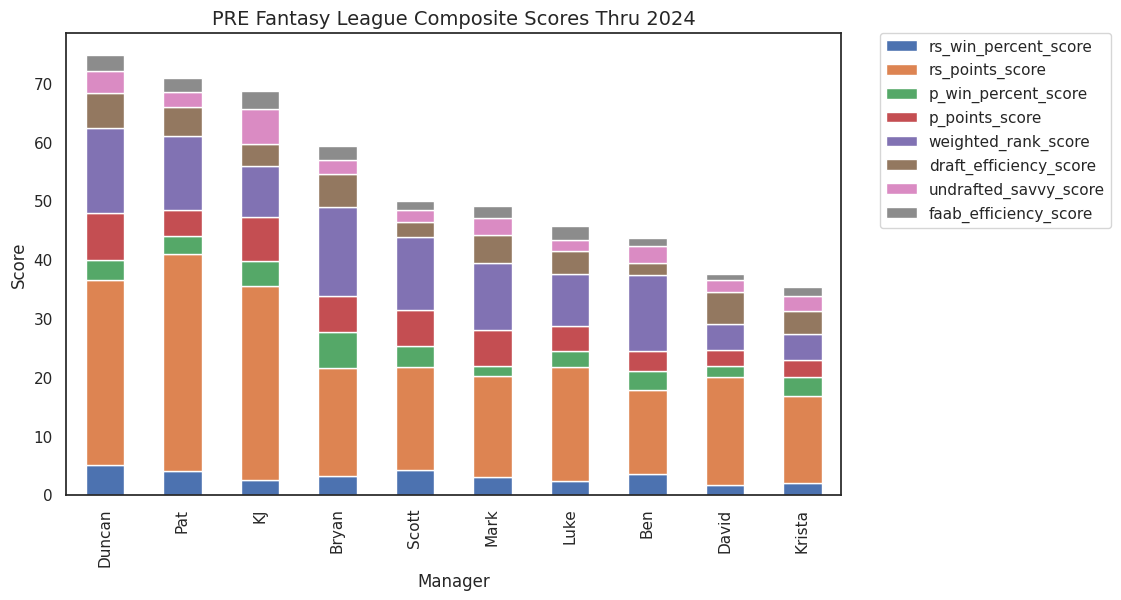

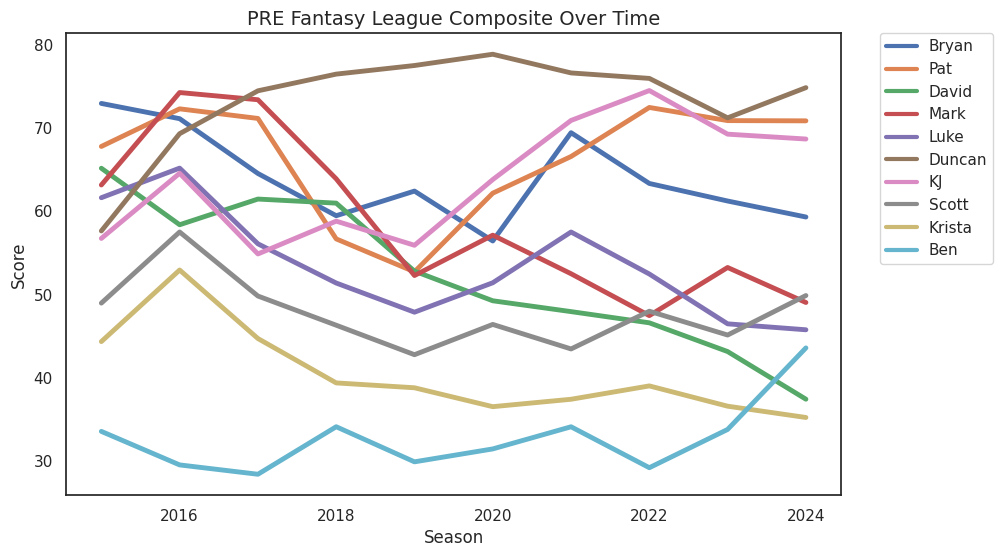

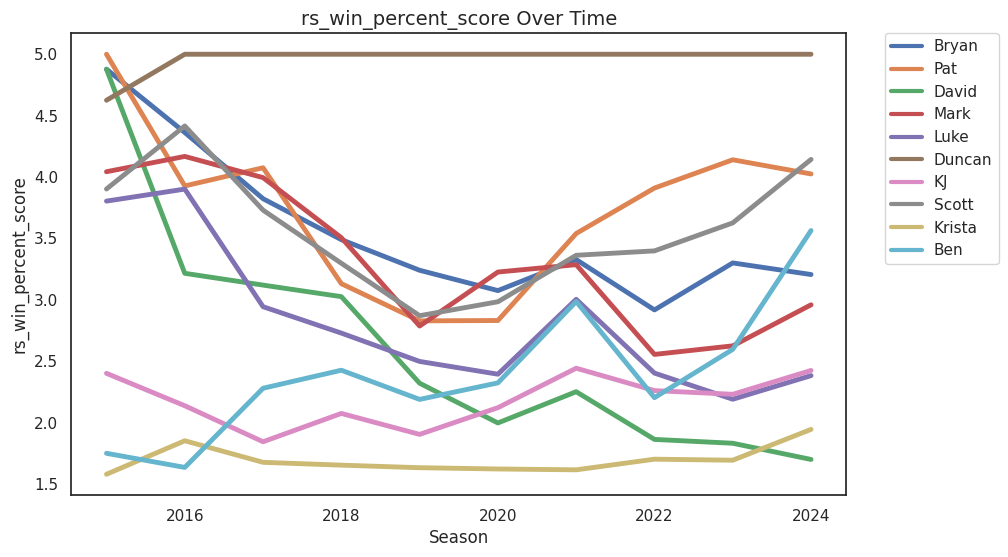

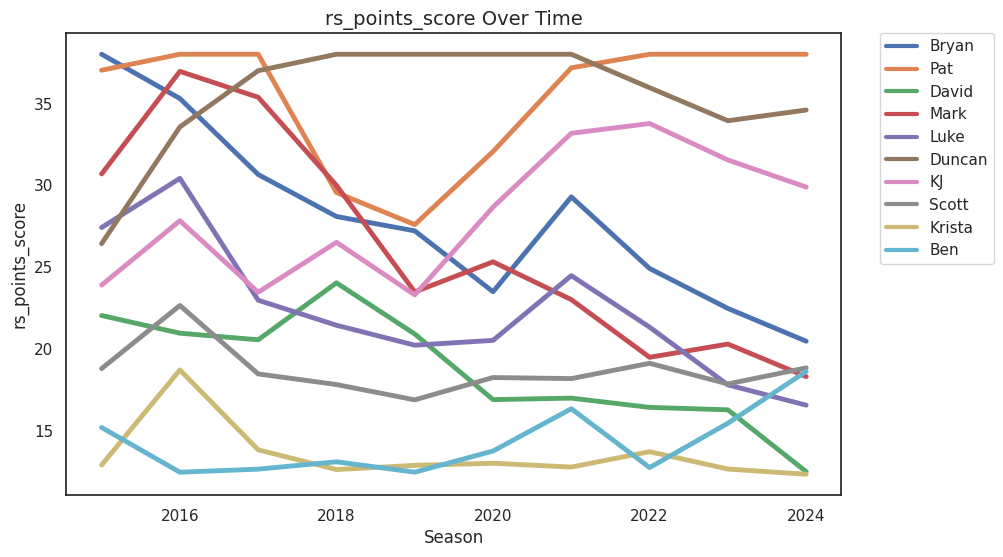

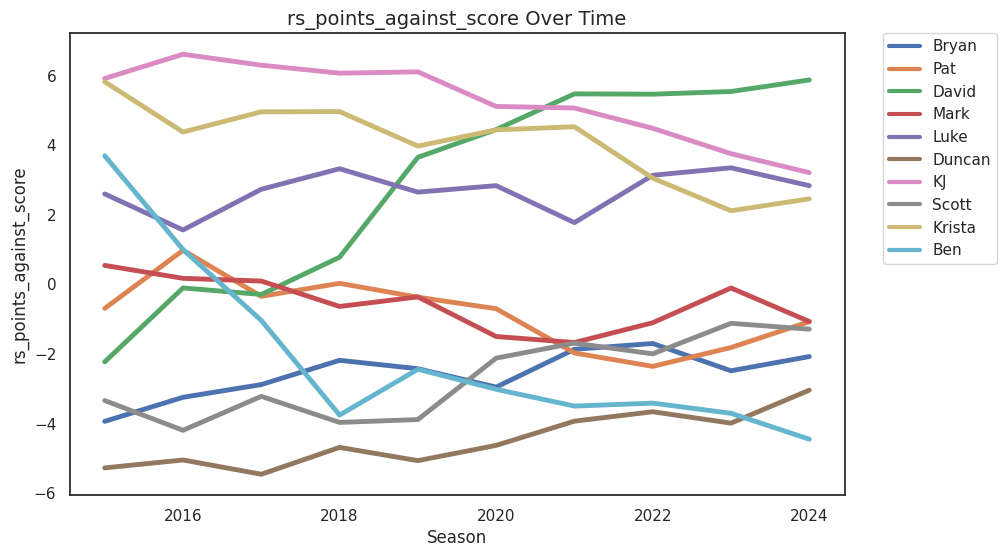

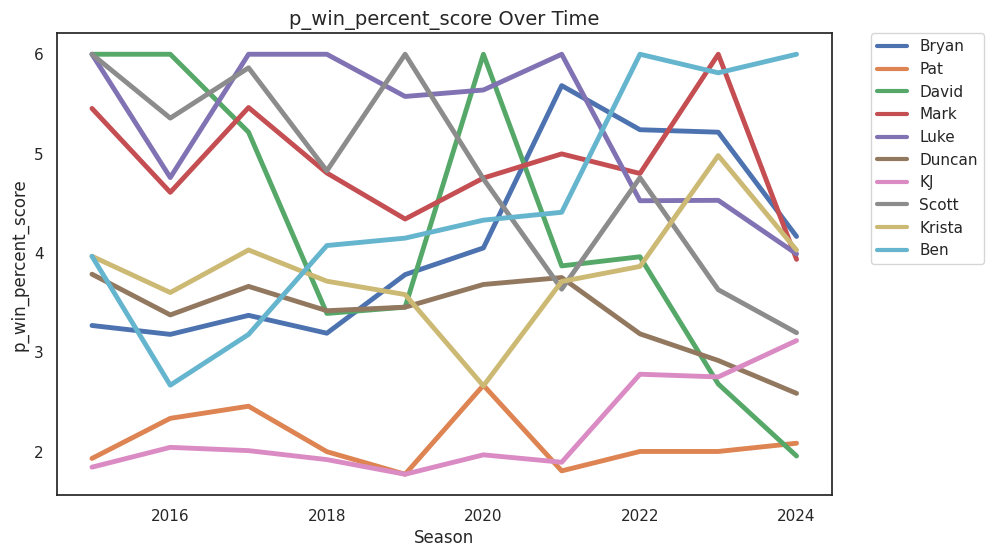

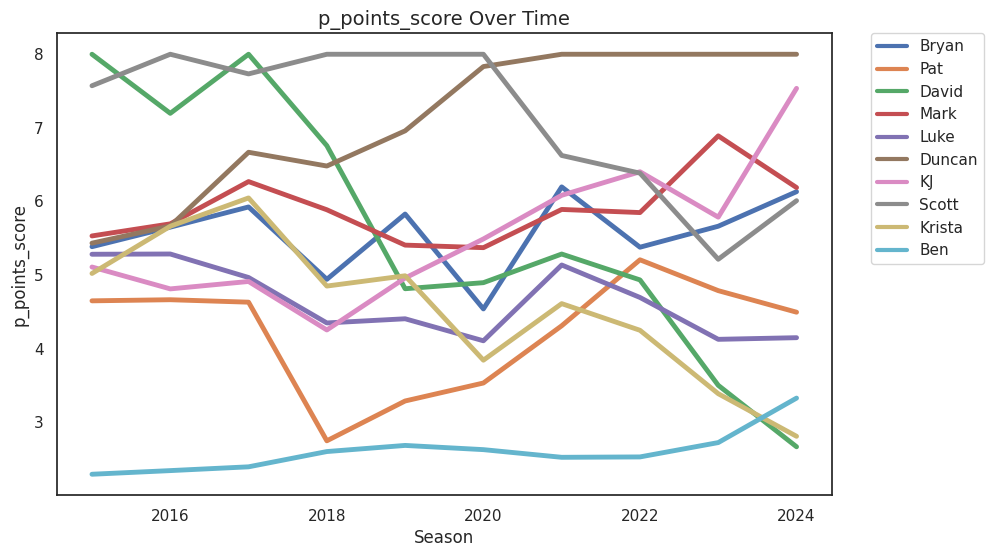

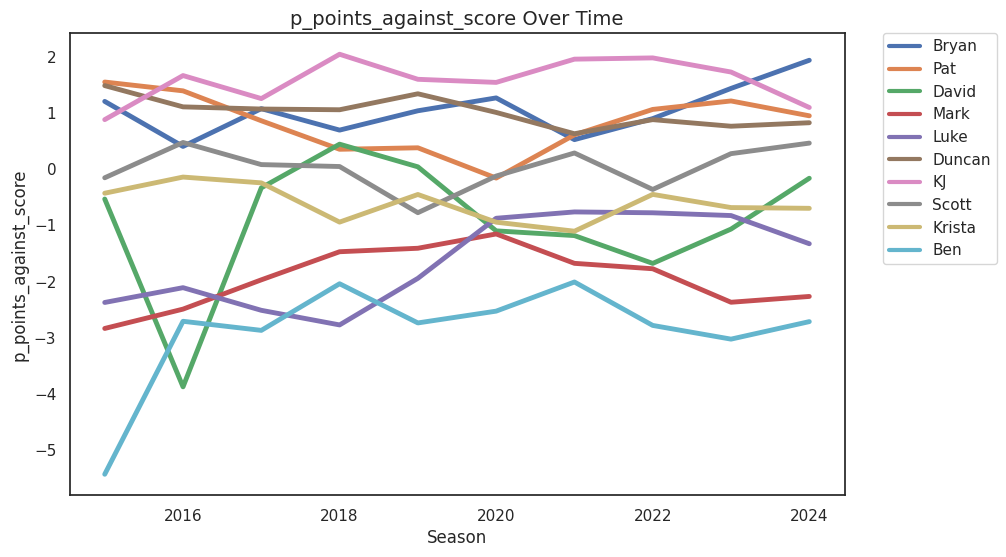

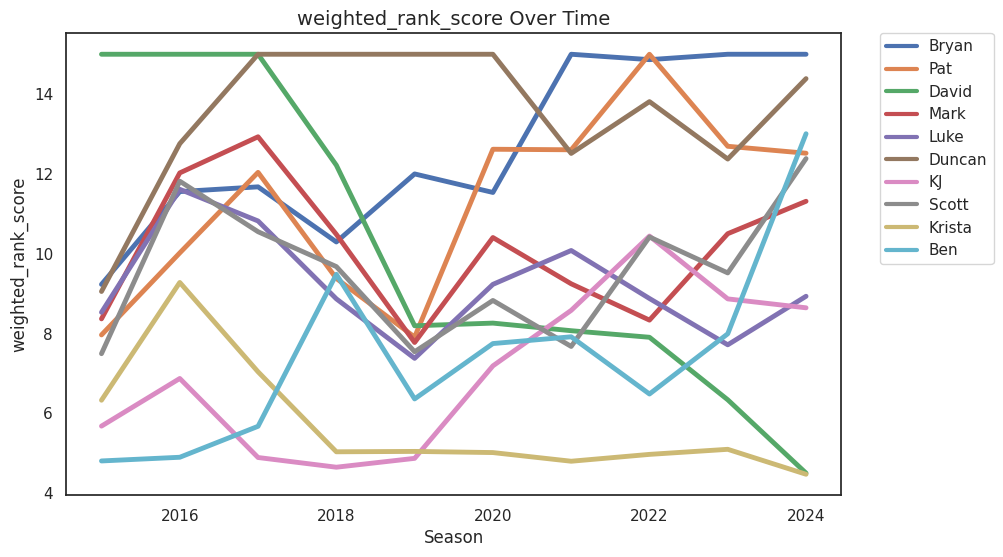

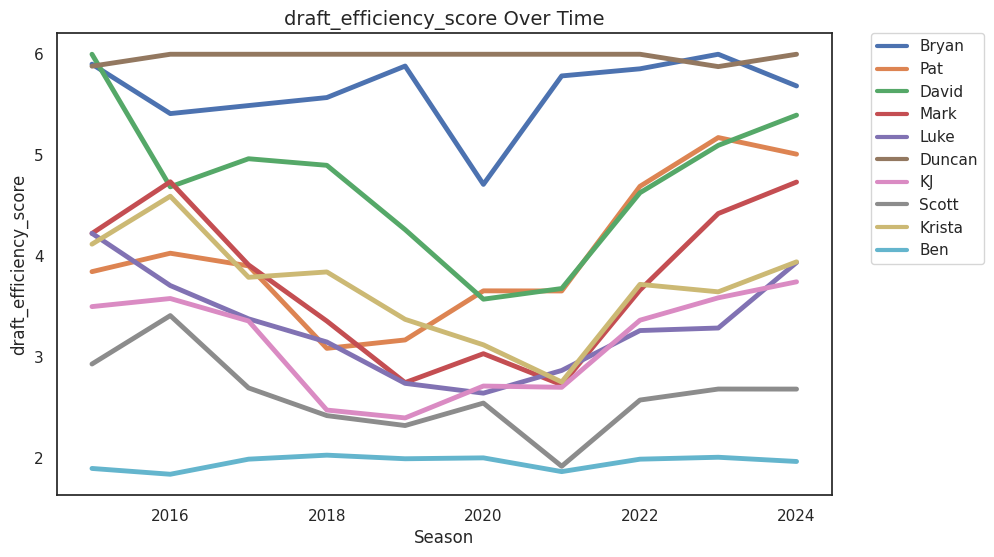

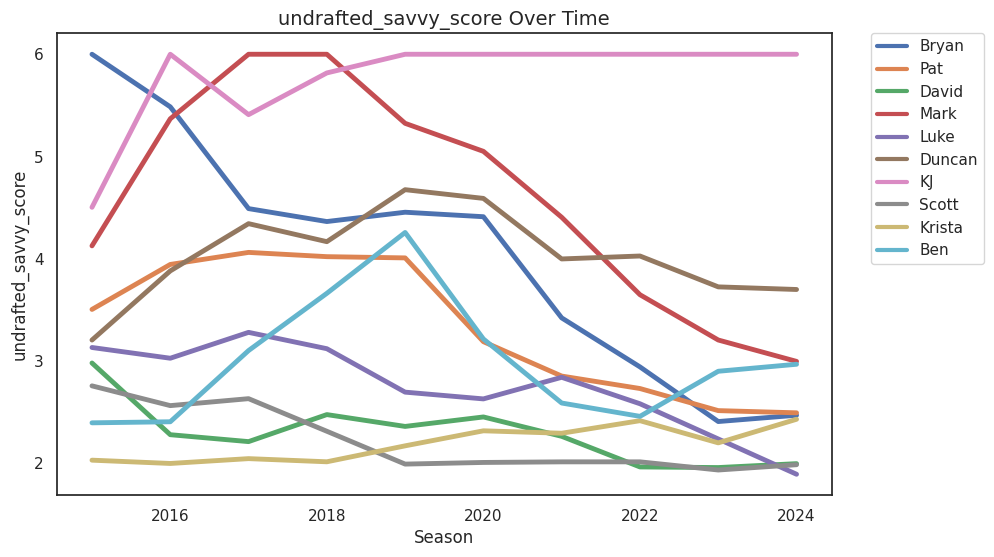

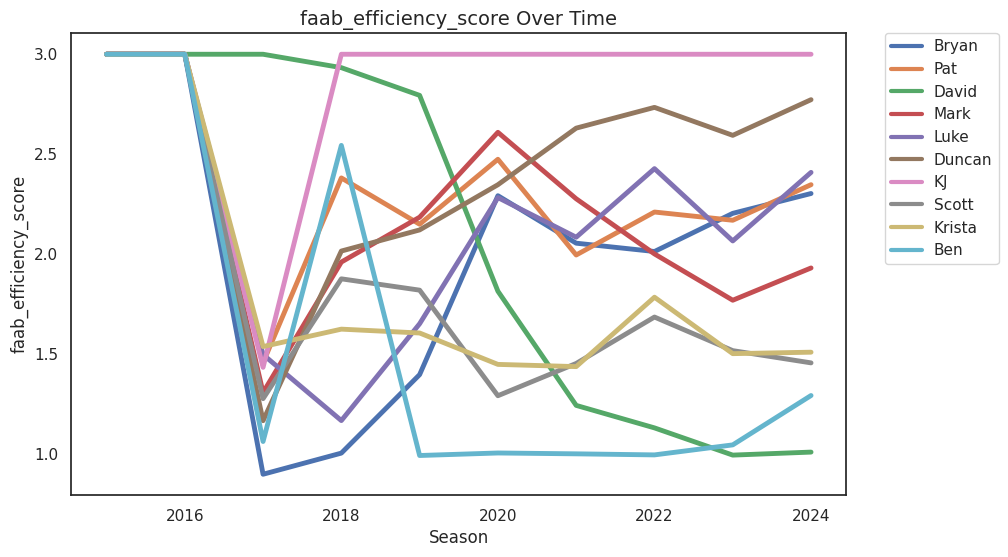

,avg_rs_win_percent,rs_win_percent_score,rs_points_z_score,rs_points_score,rs_points_against_z_score,rs_points_against_score,avg_p_win_percent,p_win_percent_score,p_points_z_score,p_points_score,...,weighted_rank,weighted_rank_score,draft_efficiency,draft_efficiency_score,undrafted_avg_z_score,undrafted_savvy_score,avg_faab_efficiency,faab_efficiency_score,total_score,thru
manager,,,,,,,,,,,,,,,,,,,,,
Duncan,0.579985,5.000000,0.438610,33.944102,-0.498160,-3.985283,0.386214,2.918030,0.306944,8.000000,...,8.562500,12.372967,0.411104,5.877448,0.343170,3.723730,0.190920,2.593735,71.205552,2023
Pat,0.554459,4.140347,0.553167,38.000000,-0.226710,-1.813681,0.297634,2.002529,-0.028082,4.786847,...,8.671875,12.692901,0.263088,5.173825,-0.079867,2.512924,0.223025,2.168314,70.873933,2023
KJ,0.469723,2.229884,0.362915,31.550166,0.469176,3.753408,0.371265,2.752696,0.098895,5.786002,...,7.203125,8.867340,-0.156791,3.584401,0.779343,6.000000,0.164790,3.000000,69.247774,2023
Bryan,0.522665,3.299977,0.054746,22.491315,-0.310174,-2.481395,0.526147,5.215641,0.084035,5.662443,...,9.339286,15.000000,0.436358,6.000000,-0.128770,2.406035,0.219987,2.202999,61.229594,2023
Mark,0.492273,2.624480,-0.048983,20.317627,-0.012984,-0.103870,0.561483,6.000000,0.210441,6.890552,...,7.906250,10.501747,0.080554,4.420298,0.182649,3.203828,0.259999,1.767702,53.254948,2023
Luke,0.467033,2.189483,-0.180830,17.829146,0.418549,3.348390,0.490381,4.529922,-0.124283,4.125077,...,6.625000,7.716183,-0.260076,3.284970,-0.210327,2.235359,0.232236,2.064802,46.496811,2023
Scott,0.536020,3.626143,-0.177563,17.883575,-0.139795,-1.118361,0.437976,3.630208,0.028850,5.213382,...,7.500000,9.518558,-0.487875,2.679732,-0.370362,1.931791,0.287560,1.515208,45.153589,2023
David,0.442720,1.830937,-0.272584,16.304961,0.692482,5.539855,0.364447,2.681569,-0.229740,3.499926,...,5.850000,6.338066,0.244519,5.096121,-0.356323,1.955672,0.357740,0.991871,43.171807,2023
Krista,0.431515,1.692759,-0.520124,12.692019,0.264323,2.114585,0.514242,4.980313,-0.252395,3.385978,...,5.000000,5.096536,-0.136657,3.643736,-0.229836,2.197427,0.289482,1.500109,36.618777,2023


In [ ]:
# START YEAR
start_year=2015         # Year you'd like to begin calculating the overall scores up to that year.  Please enter a value >=2012...I think it will break if you go further back.

# RECENCY BONUS
recency_bonus = .25    # Percent (%) value to increase the impact of recent seasons. A good recent season will boost score more; a bad recent season will diminish score more.
recency_window = 4      # Number of recent seasons that we will give a boost to. For example, 4 will boost the impact of 2019, 2020, 2021, and 2022.

# MODEL-DERIVED METRIC WEIGHTS
use_model_weights=False                # To use model weights, set this value to "True". Doing so will cause code to ignore the USER-defined weights. If "False" this section is ignored.
manager_controlled_overall_weight=.75  # Overall weight for: rs_points,playoff_points,draft_efficiency,faab_efficiency,undrafted_savvy
win_percentages_overall_weight=.12     # Overall weight for: rs_win_percentage,playoff_win_percentage
points_against_overall_weight=.13      # Overall weight for: rs_points_against,playoff_points_against
season_rank_weight=15                  # Raw weight value for the season rank metric. All other metric weights are calculated based on this: 100 - season_rank-weight = available weight for other metrics

# USER-DEFINED METRIC WEIGHTS          # Modify the weights however you like. For best results, I recommend that you ensure that they sum to 100.
Metrics_dict = {
    #metrics getting at effectiveness of player management
    'draft_efficiency':6,
    'faab_efficiency':3,
    'undrafted_savvy':6,
    #regular season performance
    'rs_win_percentage':5,
    'rs_points':38,
    'rs_points_against':8,
    #playoff performance
    'playoff_win_percentage':6,
    'playoff_points':8,
    'playoff_points_against':5,
    #overall
    'season_rank':15,
}

#---------------------------------DO NOT MODIFY BELOW THIS LINE------------------------------------

pre_managers = ['Benjamin','Bryan','David Casstevens','Duncan','Kevin','Krista','Luke','Mark','Patrick','Scott Gunter']
compiled_final_scores, raw_scores = calculate_composite_ranks(Master,start_year,pre_managers,recency_bonus,recency_window,Metrics_dict
                                                              ,use_model_weights,manager_controlled_overall_weight,
                                                              win_percentages_overall_weight,points_against_overall_weight,season_rank_weight)
compiled_final_scores[compiled_final_scores.thru==2023] #well, you can change this year if you want

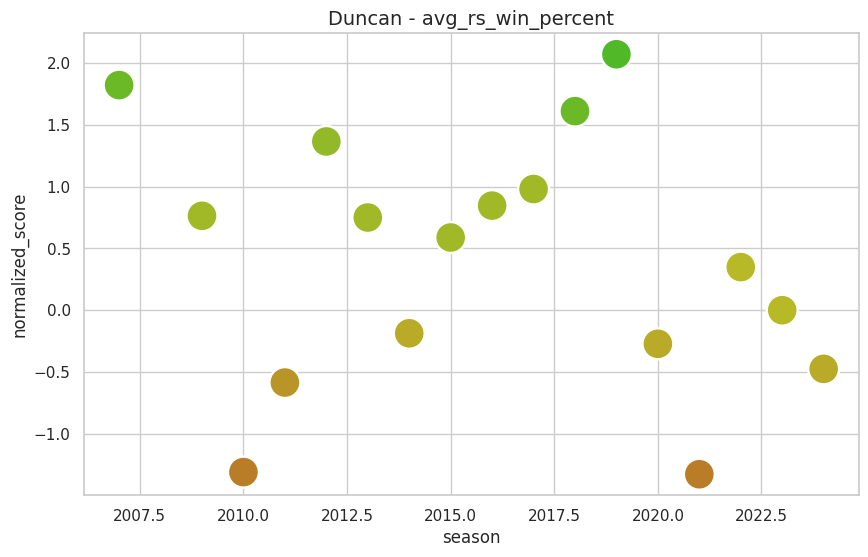

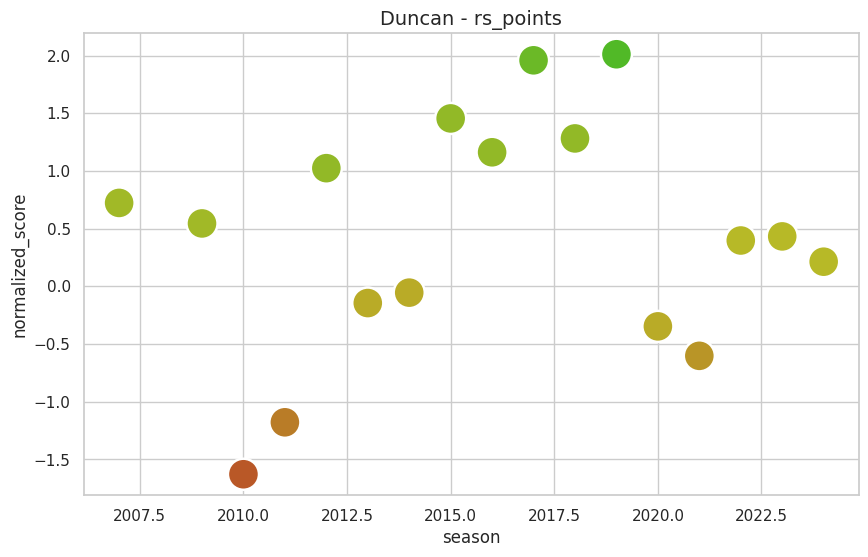

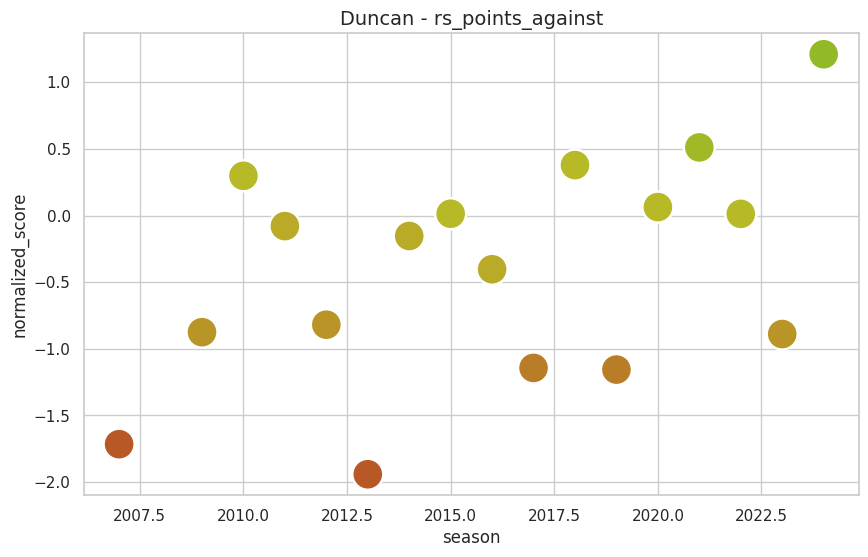

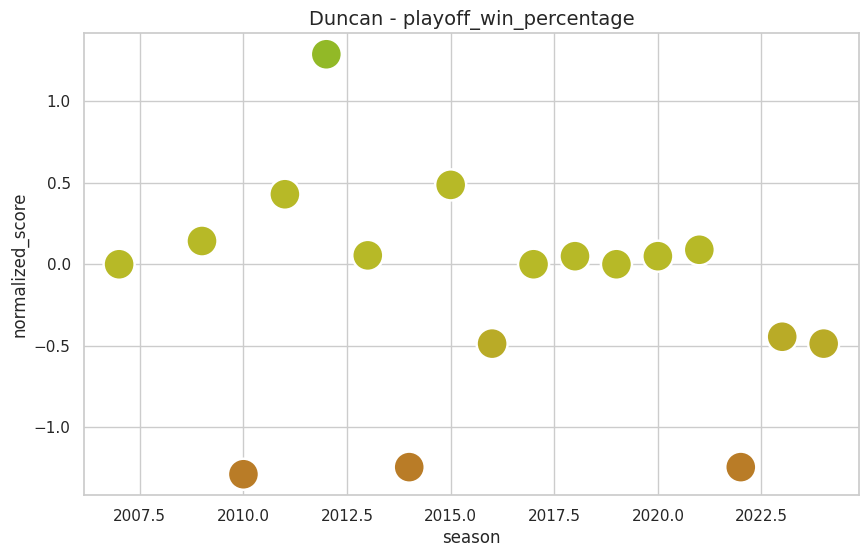

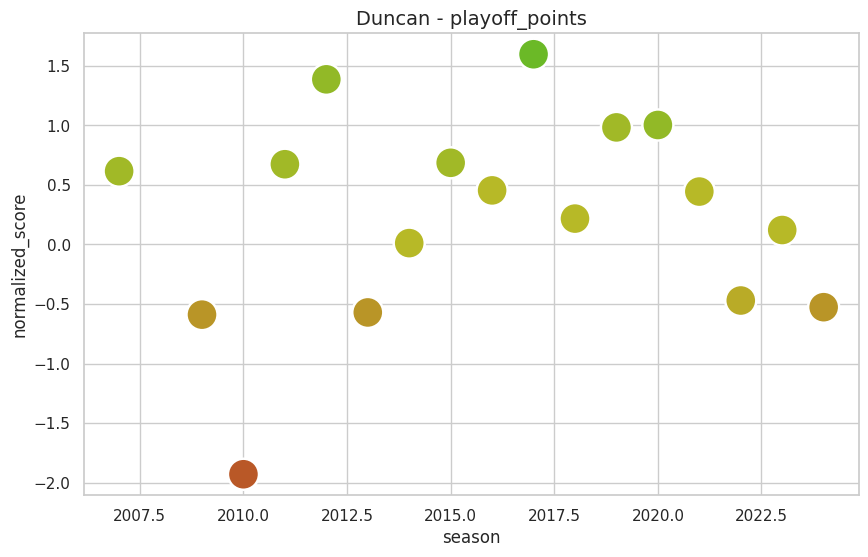

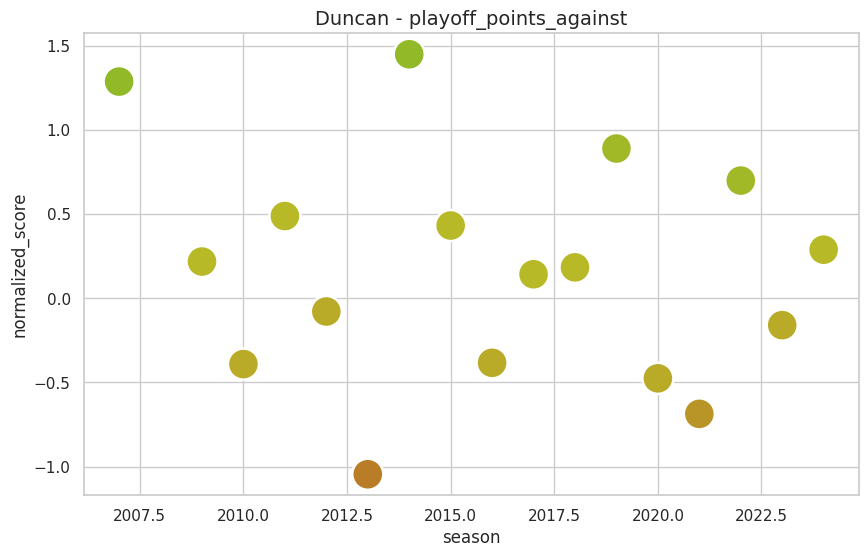

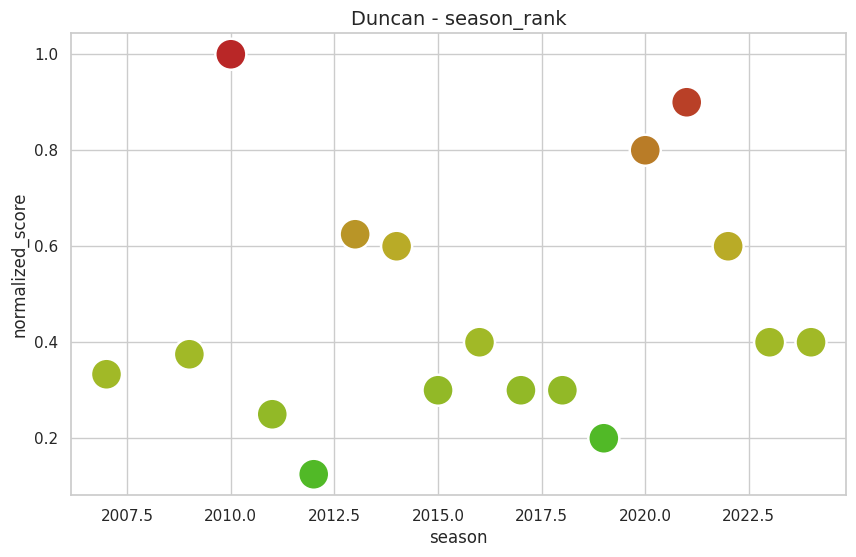

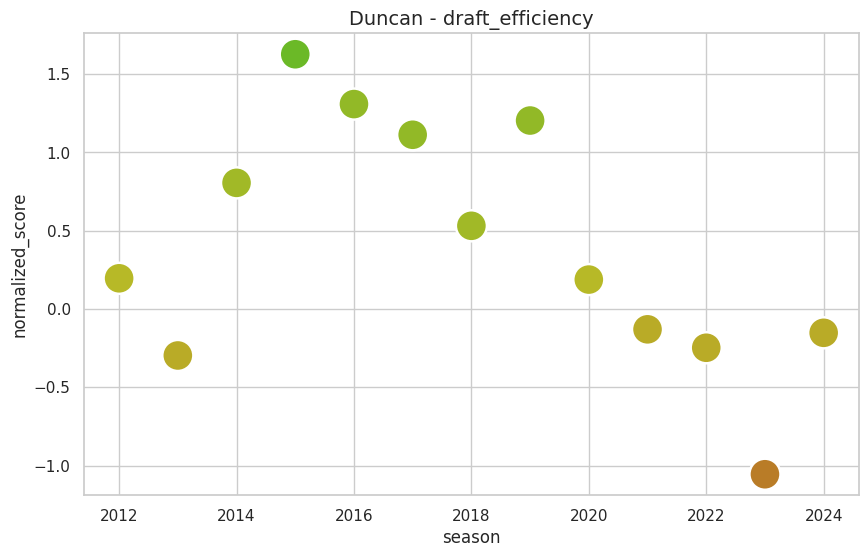

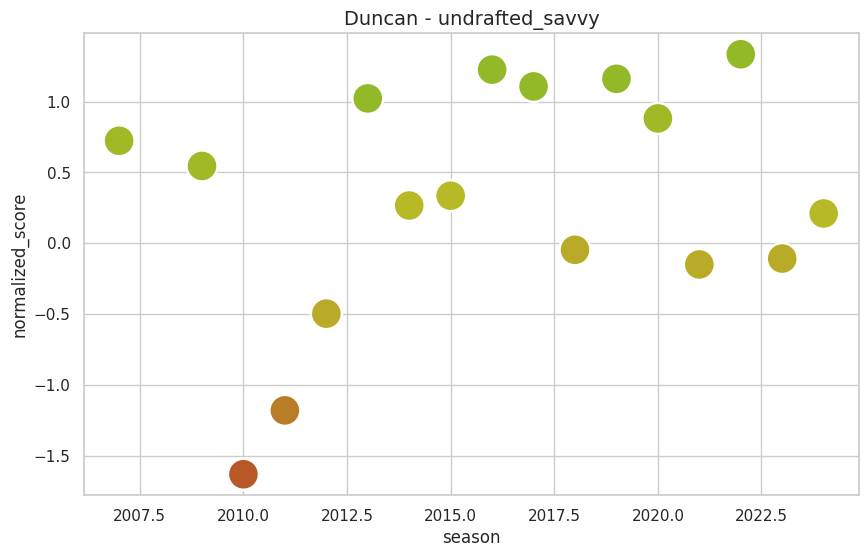

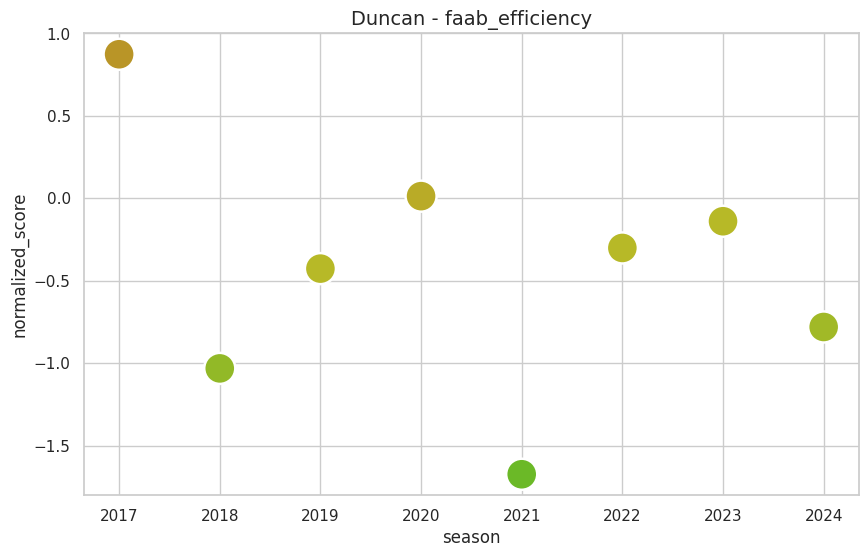

In [ ]:
# MANAGER SPOTLIGHT
# See raw metric values over time for a specific manager. All values have been normalized to standardize the scale between metrics.
# Dots are color-coded for 'good' scores (green), 'OK' scores (yellow), and 'bad' scores (red)

# For manager, enter from list: Ben, Bryan, David, Duncan, KJ, Krista, Luke, Mark, Pat, Scott
manager_spotlight('Duncan',raw_scores)

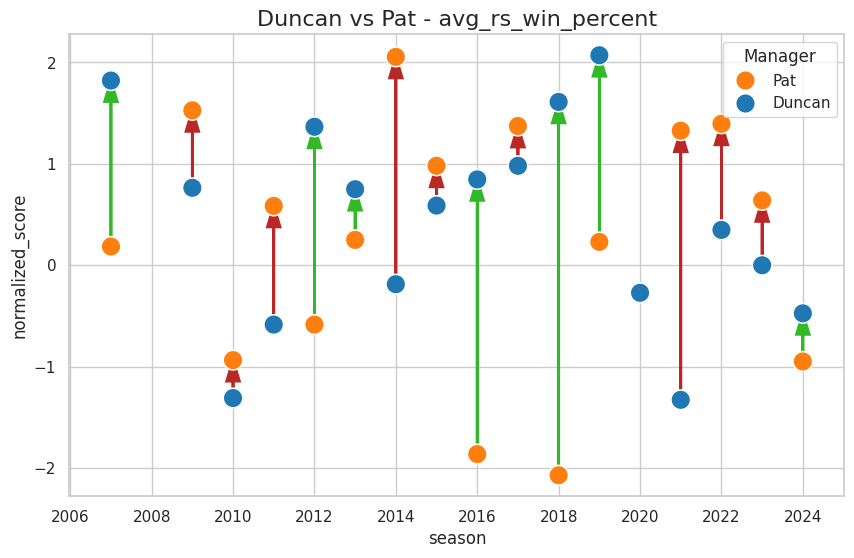

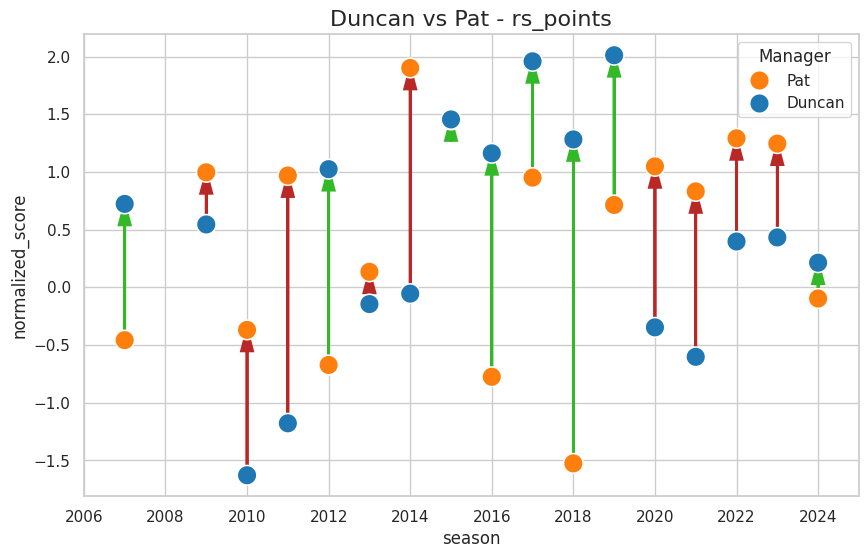

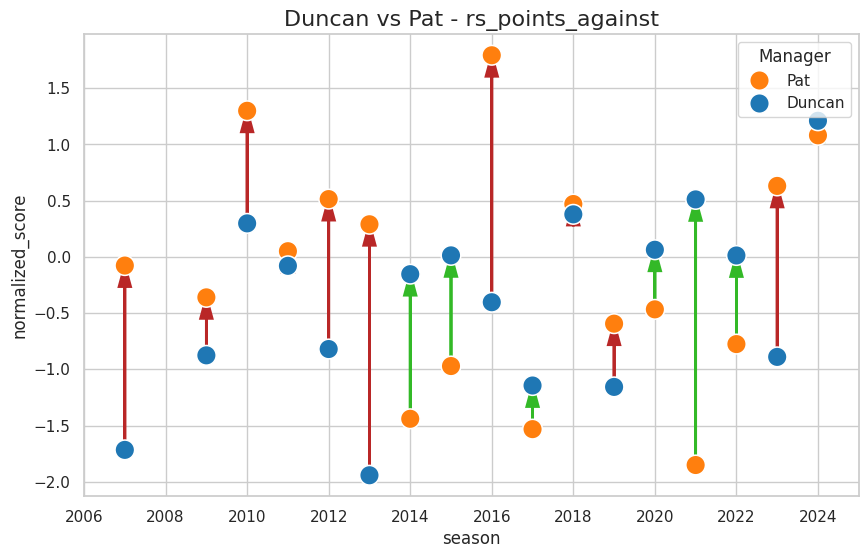

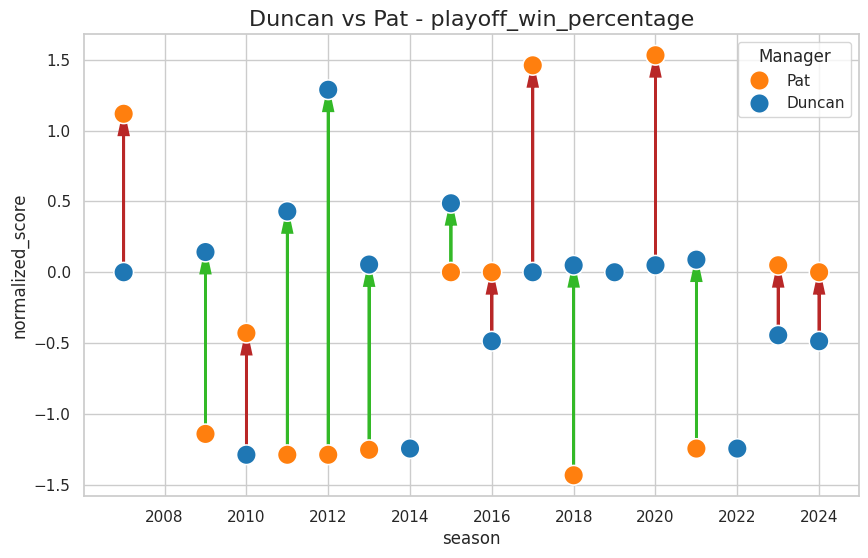

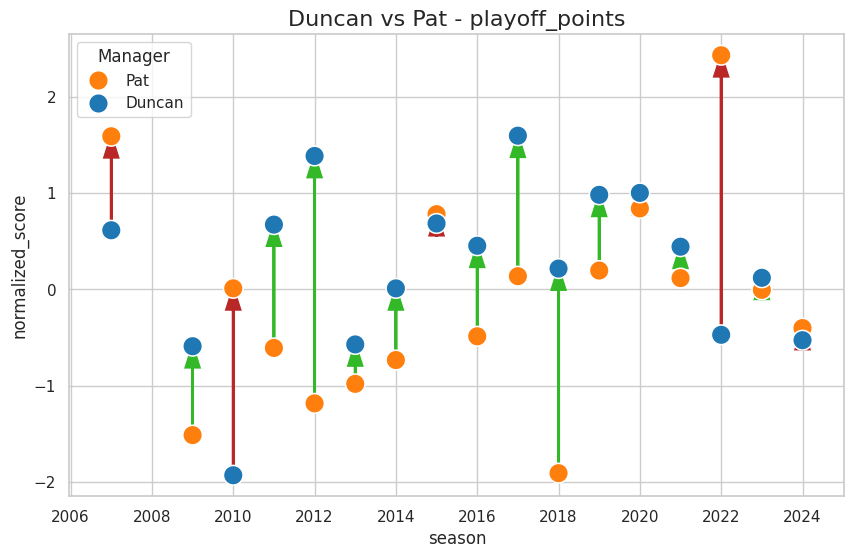

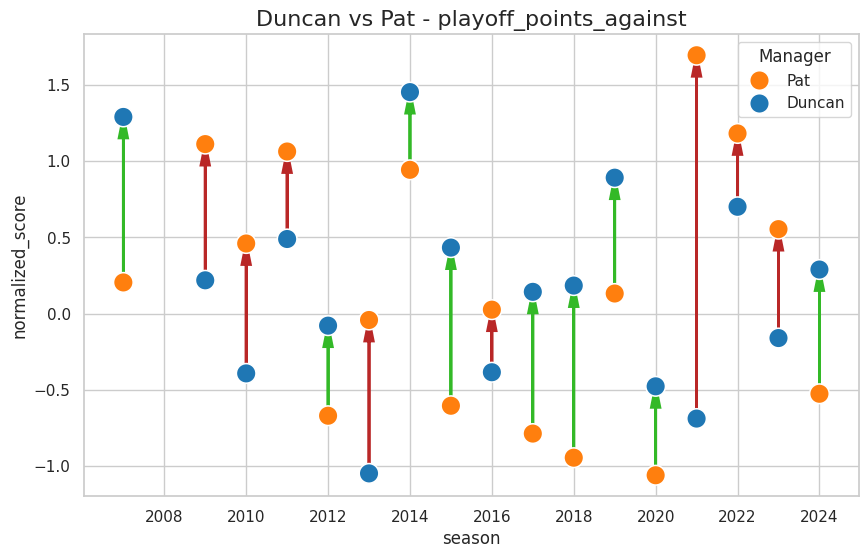

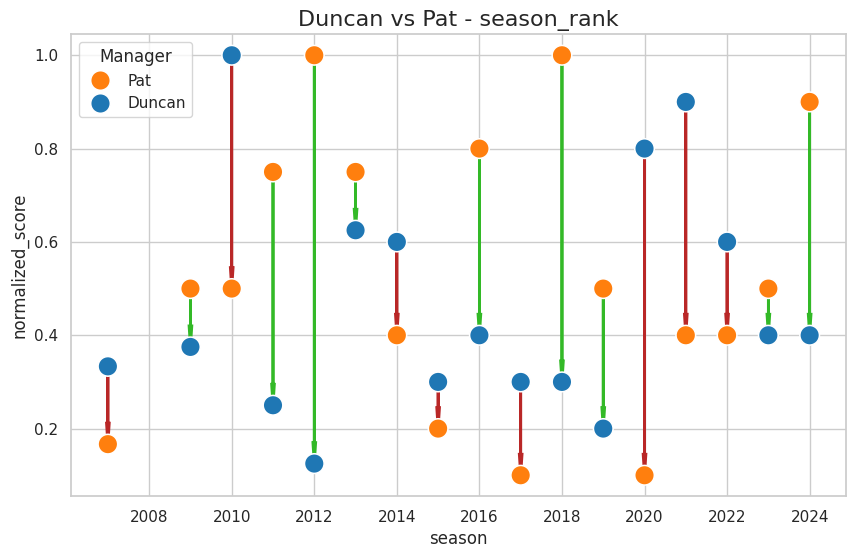

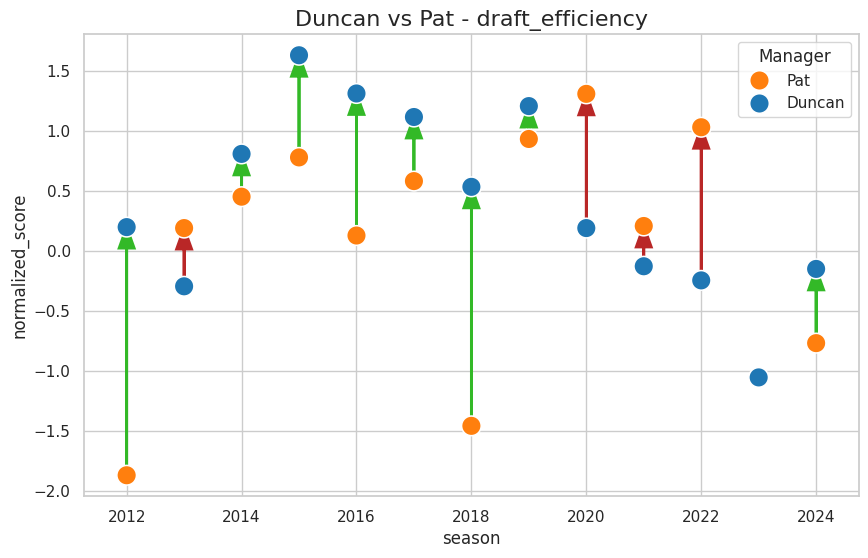

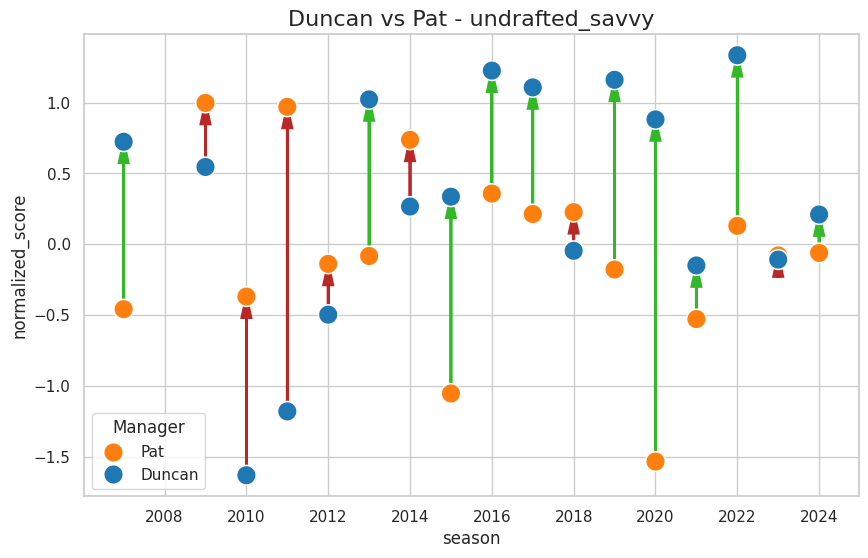

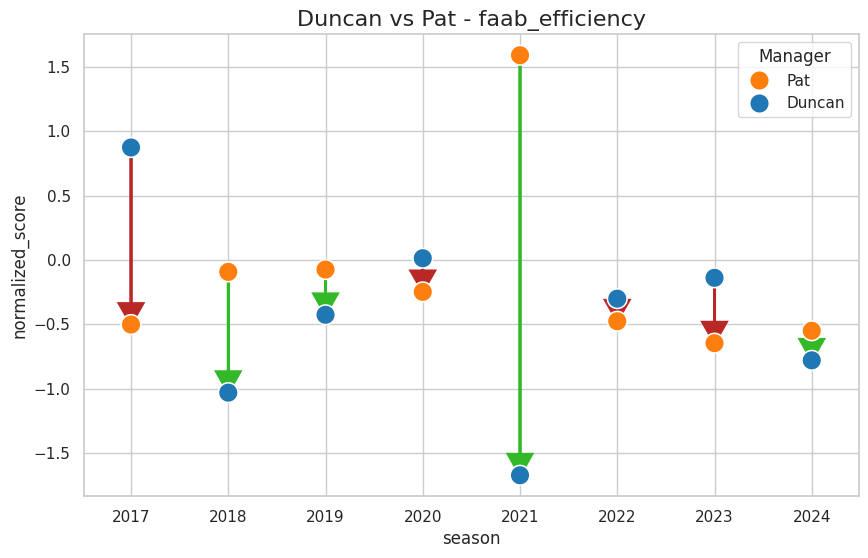

In [ ]:
# MANAGER COMPARISON

# Compare metric scores for two managers side-by-side.  The first manager will be compared to the second.
# Green arrows mean that the first manager scored better than the second that year. Red arrows mean the second manager scored better.

# Choose 2 from list: Ben, Bryan, David, Duncan, KJ, Krista, Luke, Mark, Pat, Scott
compare_managers('Duncan','Pat',raw_scores)